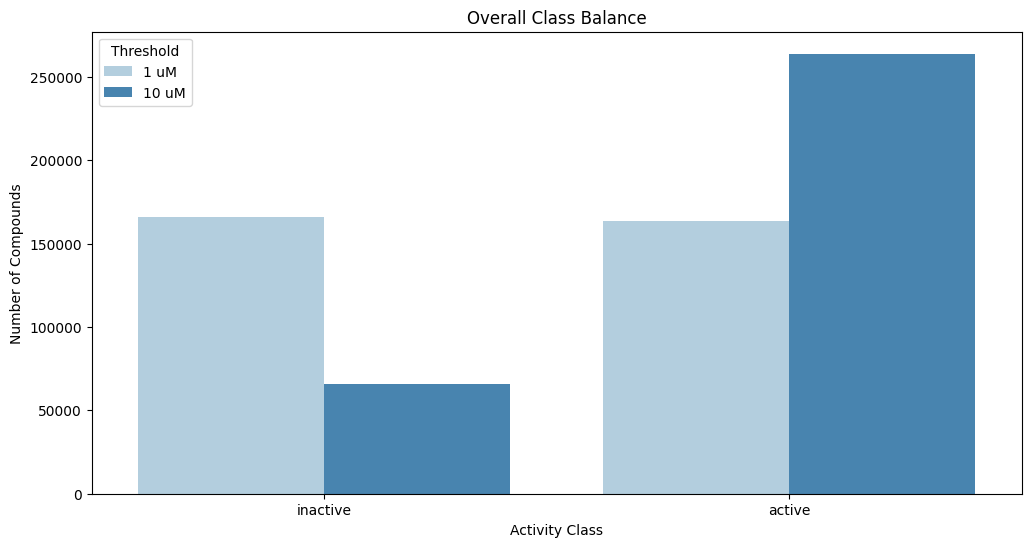

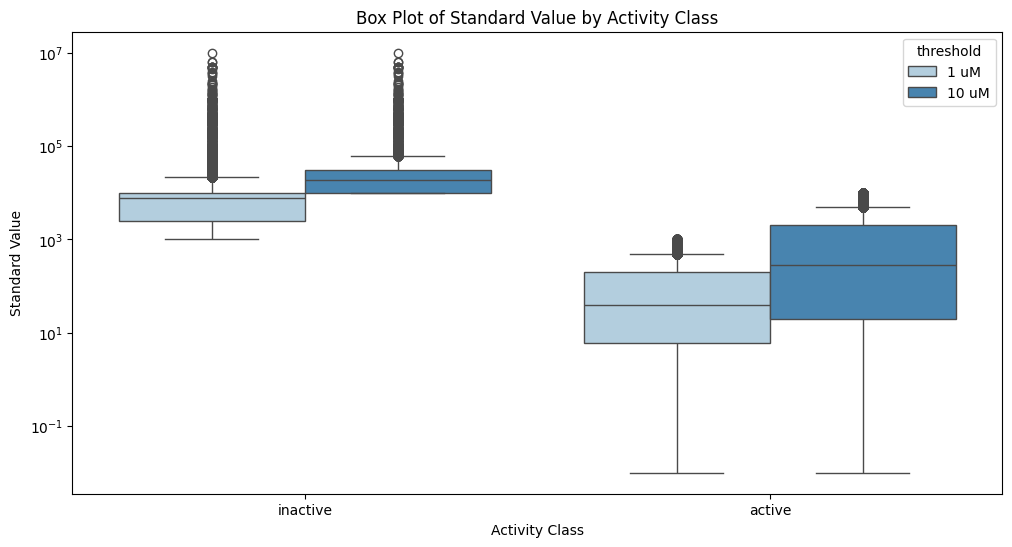

/tmp/ipykernel_1619398/3707921122.py:116: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
/tmp/ipykernel_1619398/3707921122.py:124: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)


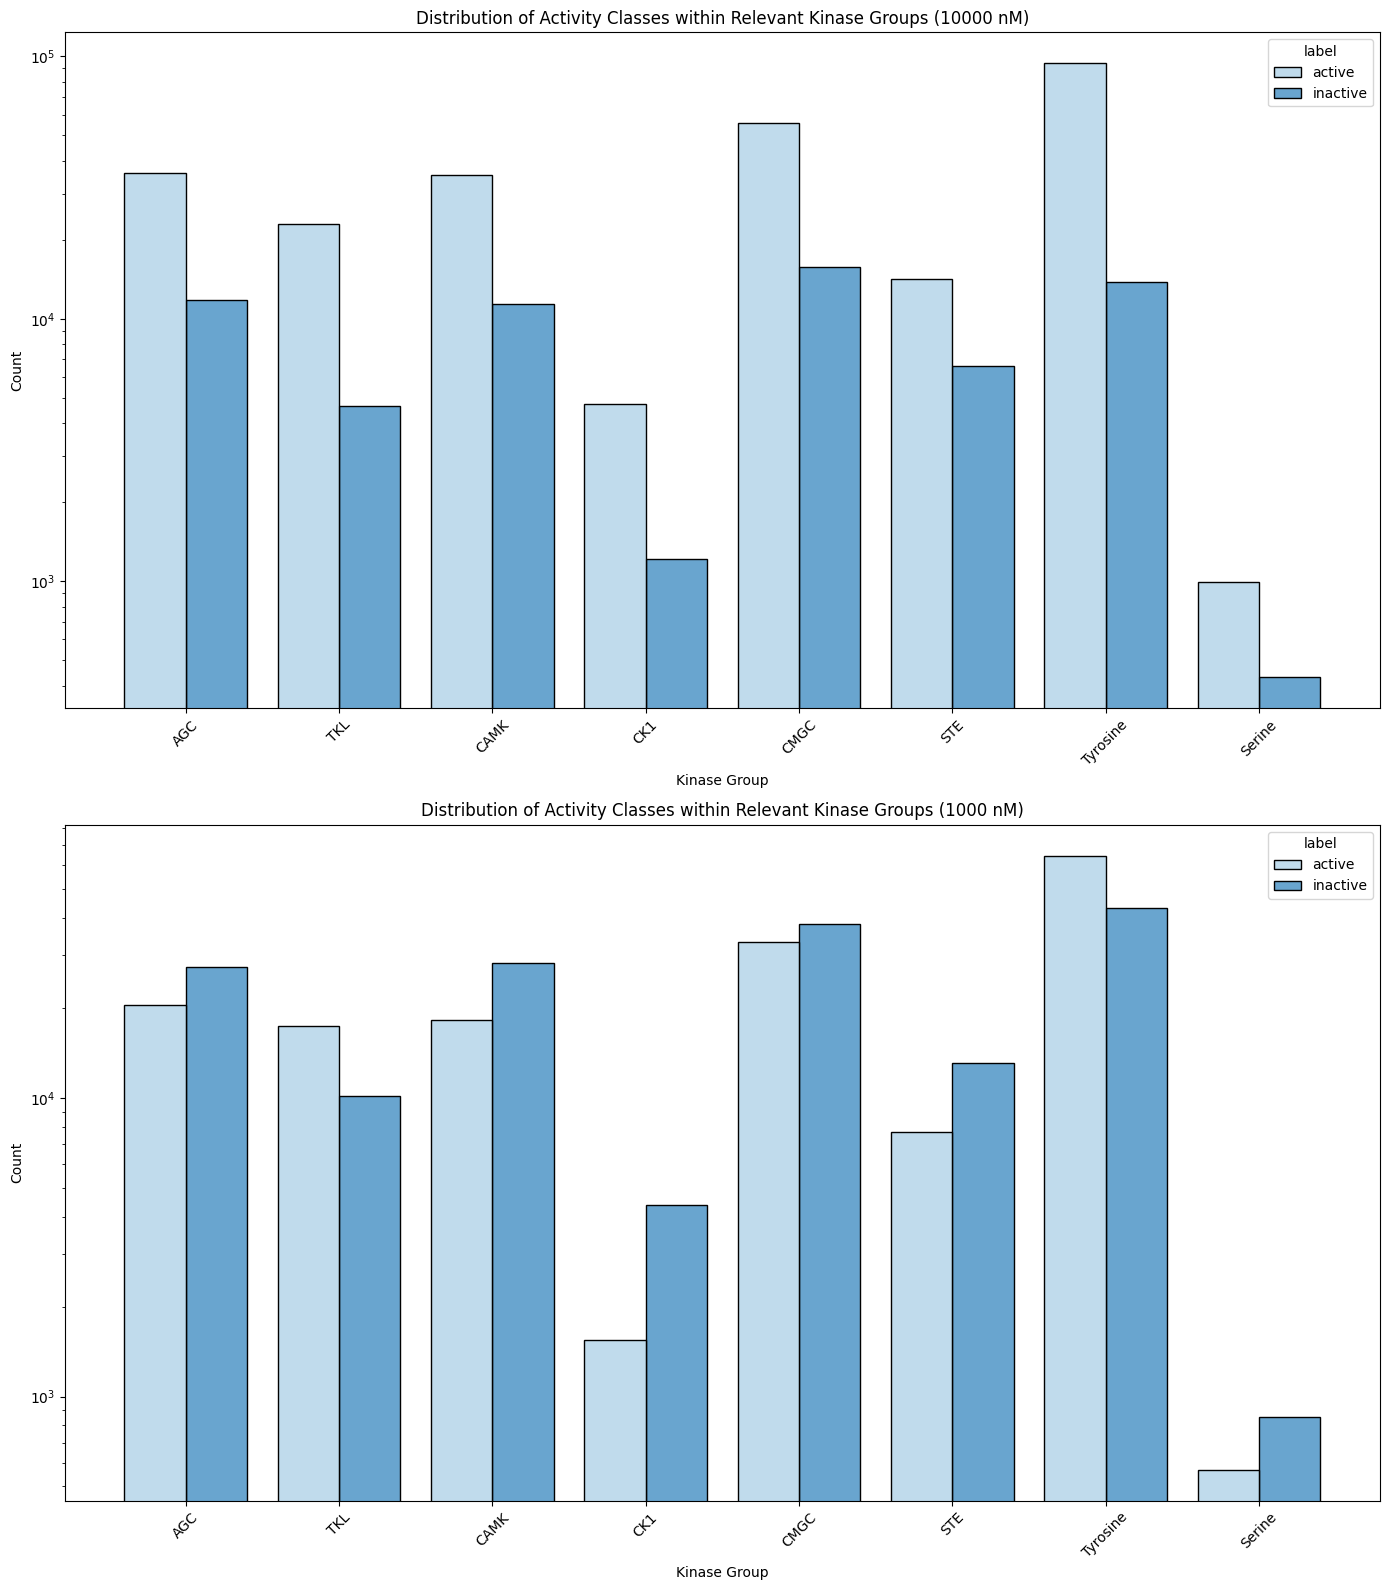

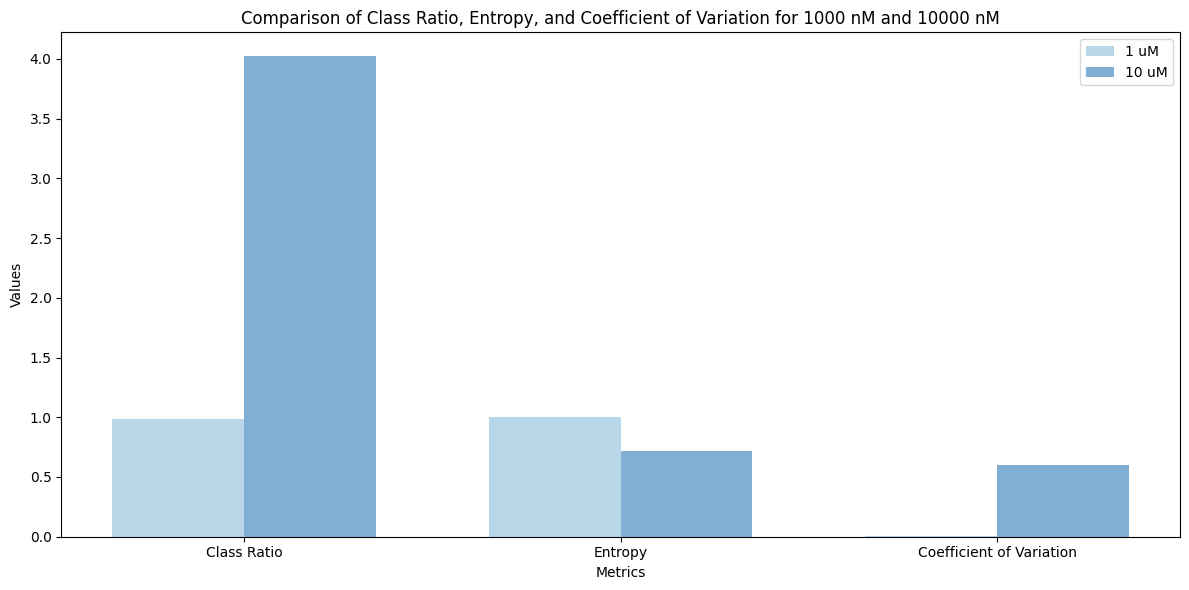

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import entropy

class CheckBalance:
    def __init__(self, filepath, activity_threshold):
        self.filepath = filepath
        self.activity_threshold = activity_threshold
        self.data = self.load_data()

    def load_data(self):
        # Load only the necessary columns
        columns = ['chembl_id', 'molregno', 'target_kinase', 'canonical_smiles',
                   'standard_value', 'standard_type', 'kinase_group']
        return pd.read_csv(self.filepath, sep='\t', usecols=columns, low_memory=False)

    def prepare_labels(self):
        # Ensure the standard_value column is numeric
        self.data['standard_value'] = pd.to_numeric(self.data['standard_value'], errors='coerce')
        # Prepare labels based on activity thresholds
        self.data['label'] = self.data['standard_value'].apply(lambda x: 'active' if pd.notna(x) and x < self.activity_threshold else 'inactive')

    def filter_relevant_groups(self):
        # Define the relevant kinase groups
        relevant_kinase_groups = [
            'AGC', 'Other', 'TKL', 'CAMK', 'CK1', 'CMGC', 'STE', 'Tyrosine',
            'Transferse', 'Serine', 'Nuclear', 'Lyase'
        ]
        self.data = self.data[self.data['kinase_group'].isin(relevant_kinase_groups)]

    def analyze_class_balance(self):
        # Ensure labels are prepared
        if 'label' not in self.data.columns:
            self.prepare_labels()

        # Filter the kinase groups to exclude irrelevant ones
        self.filter_relevant_groups()

        # Analyze class balance within each kinase group
        class_counts = self.data.groupby(['kinase_group', 'label']).size().unstack(fill_value=0)

        return self.data

    def analyze_class_metrics(self):
        # Ensure labels are prepared
        if 'label' not in self.data.columns:
            self.prepare_labels()

        # Calculate class counts and ratios
        class_counts = self.data['label'].value_counts()
        class_ratio = class_counts['active'] / class_counts['inactive'] if 'active' in class_counts and 'inactive' in class_counts else float('inf')

        # Calculate entropy
        probability_distribution = class_counts / class_counts.sum()
        data_entropy = entropy(probability_distribution, base=2)

        # Calculate the coefficient of variation
        coeff_variation = np.std(class_counts) / np.mean(class_counts)

        results = pd.DataFrame({
            "Metric": ["Class Ratio", "Entropy of Distribution", "Coefficient of Variation"],
            "Value": [class_ratio, data_entropy, coeff_variation]
        })
        results.to_csv(f'data_balance_statistics_{self.activity_threshold}.tsv', sep='\t', index=False)

        return class_ratio, data_entropy, coeff_variation

    def save_output(self):
        if 'label' not in self.data.columns:
            self.prepare_labels()

        self.filter_relevant_groups()
        self.data.to_csv(f'filtered_dataset_{self.activity_threshold}.tsv', sep="\t", index=False)

def run_analysis(activity_threshold, filepath):
    checker = CheckBalance(filepath, activity_threshold)
    checker.save_output()  # Save the output with specific rows removed
    class_ratio, data_entropy, coeff_variation = checker.analyze_class_metrics()  # Calculate and save class metrics
    data = checker.analyze_class_balance()  # Analyze and return data for balance comparison
    return data, class_ratio, data_entropy, coeff_variation

def plot_combined_results(data_1000, data_10000, metrics_1000, metrics_10000):
    # Combine datasets
    data_1000['threshold'] = '1 uM'
    data_10000['threshold'] = '10 uM'
    combined_data = pd.concat([data_1000, data_10000])

    # Plot overall class balance
    plt.figure(figsize=(12, 6))
    sns.countplot(data=combined_data, x='label', hue='threshold', palette='Blues', dodge=True)
    plt.title('Overall Class Balance')
    plt.xlabel('Activity Class')
    plt.ylabel('Number of Compounds')
    # plt.yscale('log')
    plt.legend(title='Threshold')
    plt.savefig('class_balance_overall_combined.png')
    plt.show()

    # Plot box plot for standard value by activity class
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=combined_data, x='label', y='standard_value', hue='threshold', palette='Blues')
    plt.title('Box Plot of Standard Value by Activity Class')
    plt.xlabel('Activity Class')
    plt.ylabel('Standard Value')
    plt.yscale('log')
    plt.savefig('boxplot_standard_value_by_label_combined.png')
    plt.show()

    # Plot distribution of activity classes within relevant kinase groups for each threshold separately
    fig, axes = plt.subplots(2, 1, figsize=(14, 16))

    sns.histplot(data=data_10000, x='kinase_group', hue='label', multiple="dodge", shrink=.8, palette='Blues', hue_order=['active', 'inactive'], ax=axes[0])
    axes[0].set_title('Distribution of Activity Classes within Relevant Kinase Groups (10000 nM)')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
    axes[0].set_xlabel('Kinase Group')
    axes[0].set_ylabel('Count')
    axes[0].set_yscale('log')
    # axes[0].legend(title='Activity Class')

    sns.histplot(data=data_1000, x='kinase_group', hue='label', multiple="dodge", shrink=.8, palette='Blues', hue_order=['active', 'inactive'], ax=axes[1])
    axes[1].set_title('Distribution of Activity Classes within Relevant Kinase Groups (1000 nM)')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
    axes[1].set_xlabel('Kinase Group')
    axes[1].set_ylabel('Count')
    axes[1].set_yscale('log')
    # axes[1].legend(title='Activity Class')

    plt.tight_layout()
    plt.savefig('distribution_activity_classes_kinase_groups_combined.png')
    plt.show()

    # Plot Class Ratio, Entropy, and Coefficient of Variation
    labels = ['Class Ratio', 'Entropy', 'Coefficient of Variation']
    values_1000 = list(metrics_1000)
    values_10000 = list(metrics_10000)

    x = range(len(labels))
    fig, ax = plt.subplots(figsize=(12, 6))
    bar_width = 0.35

    blues_palette = sns.color_palette('Blues', 6)
    light_blue = blues_palette[2]
    dark_blue = blues_palette[4]

    bar_1000 = ax.bar(x, values_1000, width=bar_width, label='1 uM', color=light_blue, alpha=0.6)
    bar_10000 = ax.bar([p + bar_width for p in x], values_10000, width=bar_width, label='10 uM', color=dark_blue, alpha=0.6)

    ax.set_xlabel('Metrics')
    ax.set_ylabel('Values')
    ax.set_title('Comparison of Class Ratio, Entropy, and Coefficient of Variation for 1000 nM and 10000 nM')
    ax.set_xticks([p + bar_width / 2 for p in x])
    ax.set_xticklabels(labels)
    ax.legend()

    plt.tight_layout()
    plt.savefig('class_metrics_comparison.png')
    plt.show()

def main():
    filepath = './filtered_dataset.tsv'

    data_1000, class_ratio_1000, entropy_1000, variation_1000 = run_analysis(1000, filepath)
    data_10000, class_ratio_10000, entropy_10000, variation_10000 = run_analysis(10000, filepath)  # Set activity threshold for nM (e.g., 10µM expressed as 10000 nM)

    metrics_1000 = (class_ratio_1000, entropy_1000, variation_1000)
    metrics_10000 = (class_ratio_10000, entropy_10000, variation_10000)

    plot_combined_results(data_1000, data_10000, metrics_1000, metrics_10000)

if __name__ == "__main__":
    main()


Model: DeepChem_SmilesTokenizer_PubChem_1M
Best Parameters: {'learning_rate': 2.3037814094199713e-05, 'epochs': 5}
Final Validation Loss: 0.1518502432042401
Final Validation Class Avg Accuracy: 0.9266935749555455
Final Validation Precision: 0.9286775171815982
Final Validation Recall: 0.5394590344551471
Final Validation F1 Score: 0.6681089232288658


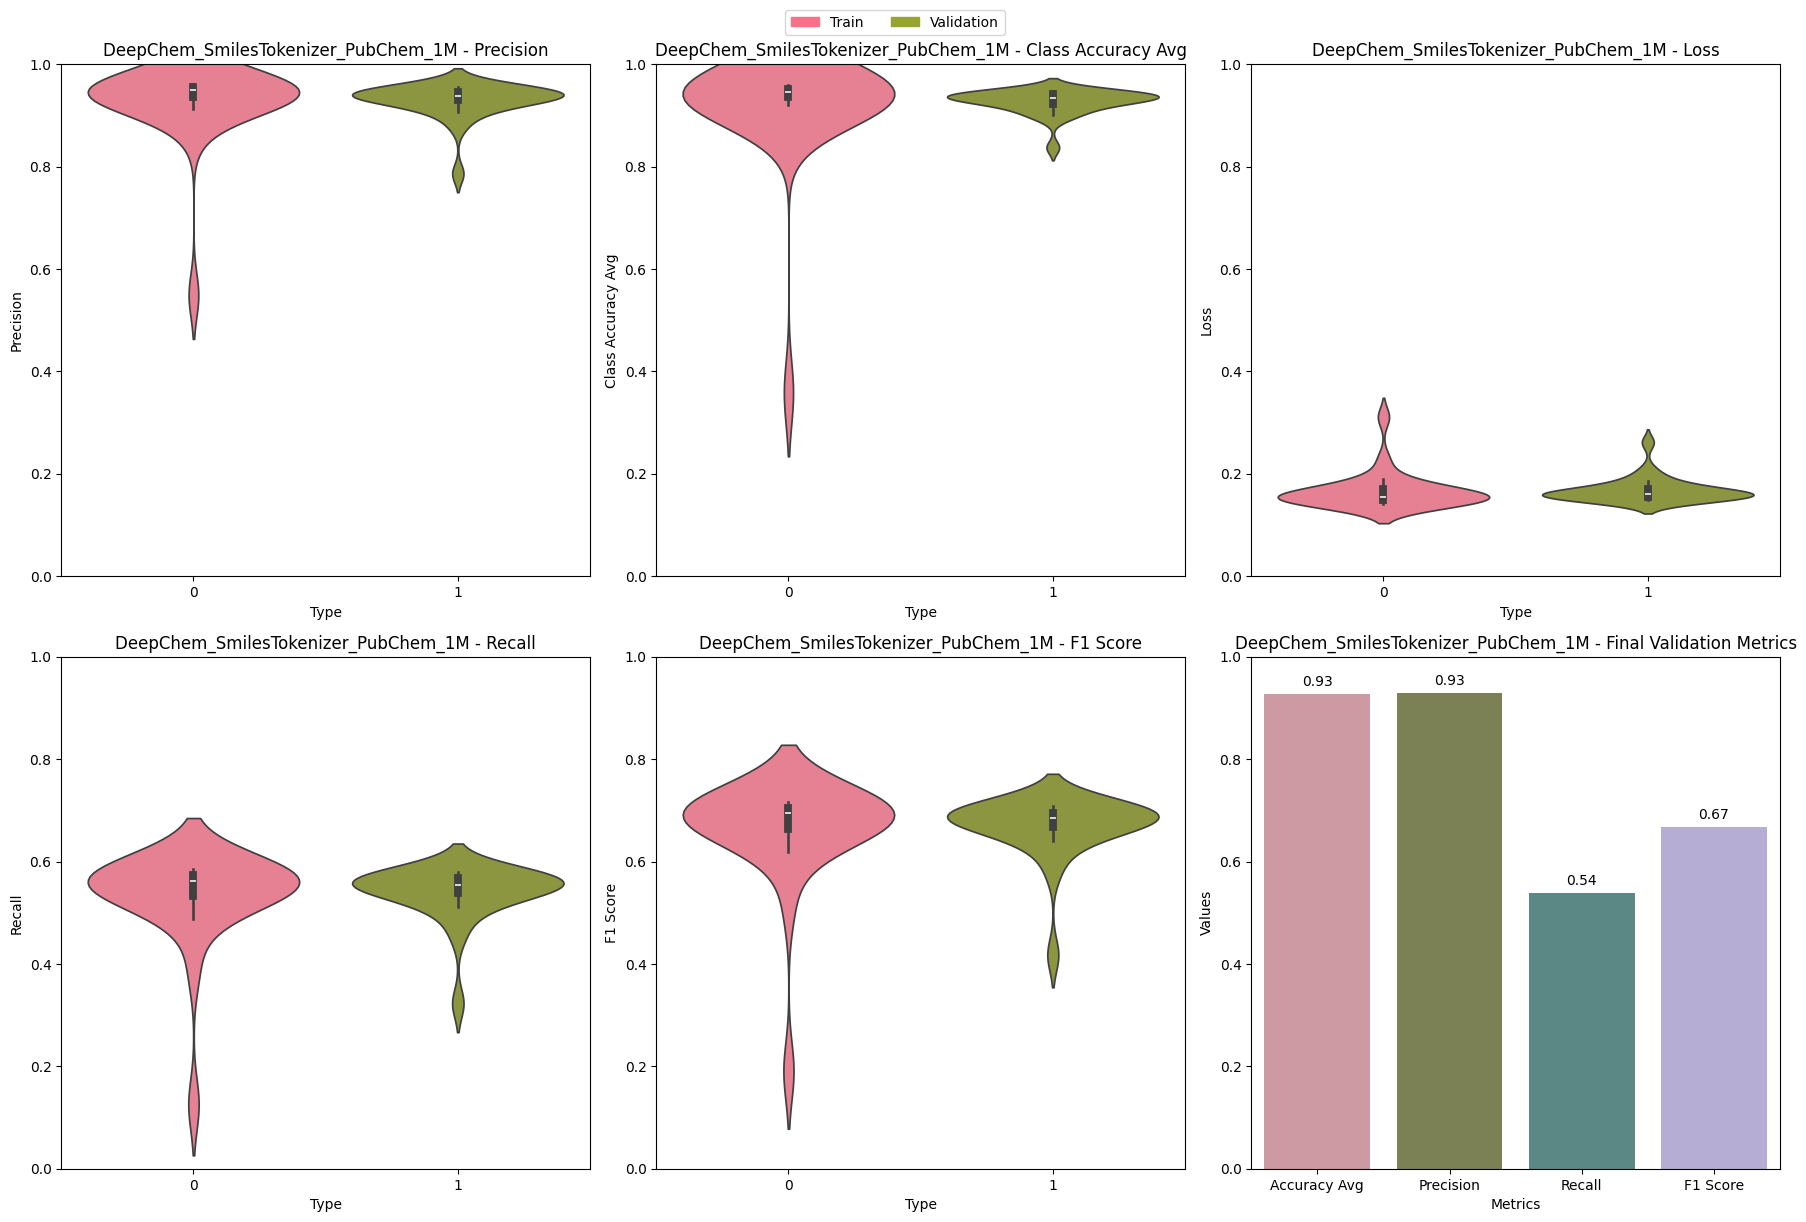


Model: DeepChem_ChemBERTa-5M-MLM
Best Parameters: {'learning_rate': 2.708507991367365e-05, 'epochs': 5}
Final Validation Loss: 0.15874135902065323
Final Validation Class Avg Accuracy: 0.9179667636664568
Final Validation Precision: 0.9178476991648465
Final Validation Recall: 0.5098559272085034
Final Validation F1 Score: 0.639098871286502


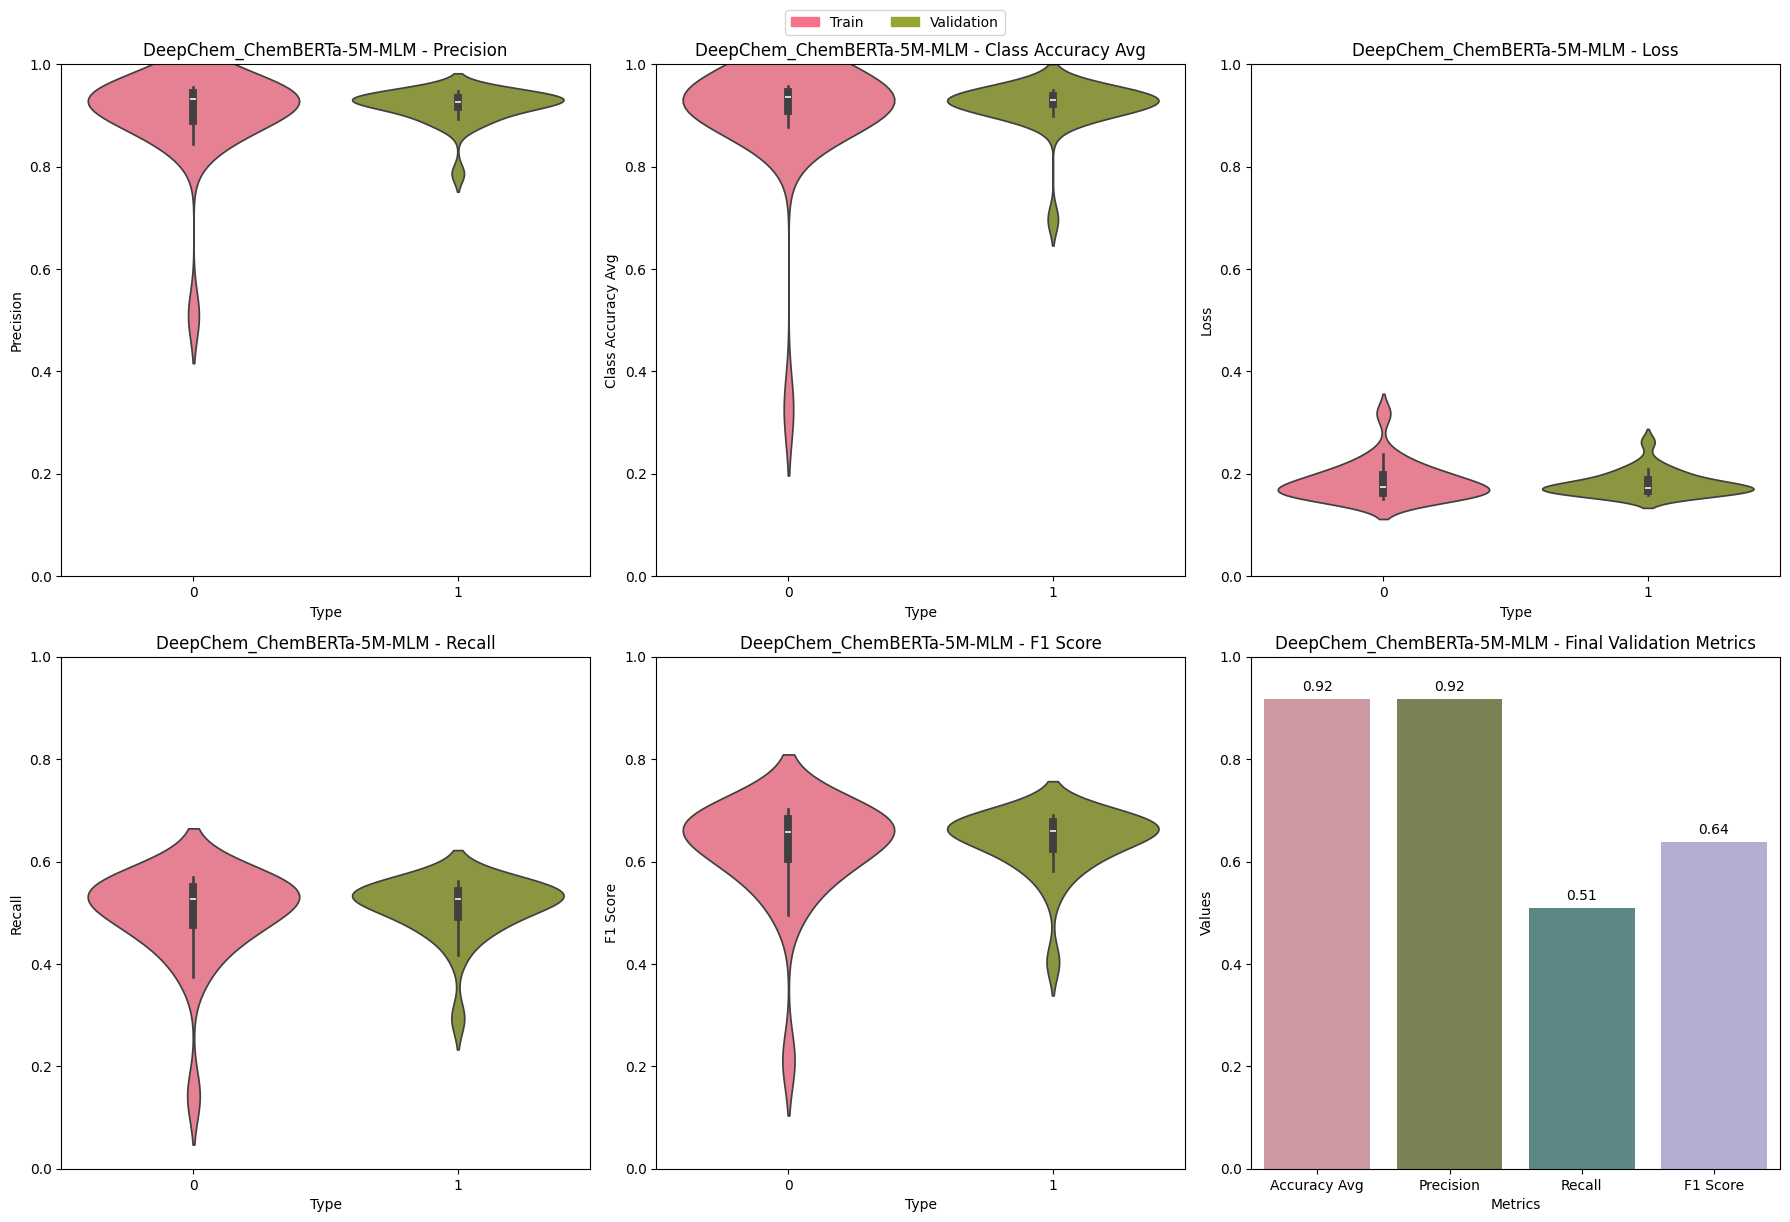


Model: DeepChem_ChemBERTa-5M-MTR
Best Parameters: {'learning_rate': 1.0385069023932177e-05, 'epochs': 5}
Final Validation Loss: 0.1777910515666008
Final Validation Class Avg Accuracy: 0.8720221370214901
Final Validation Precision: 0.8802205515997443
Final Validation Recall: 0.4497898722181
Final Validation F1 Score: 0.571720271531947


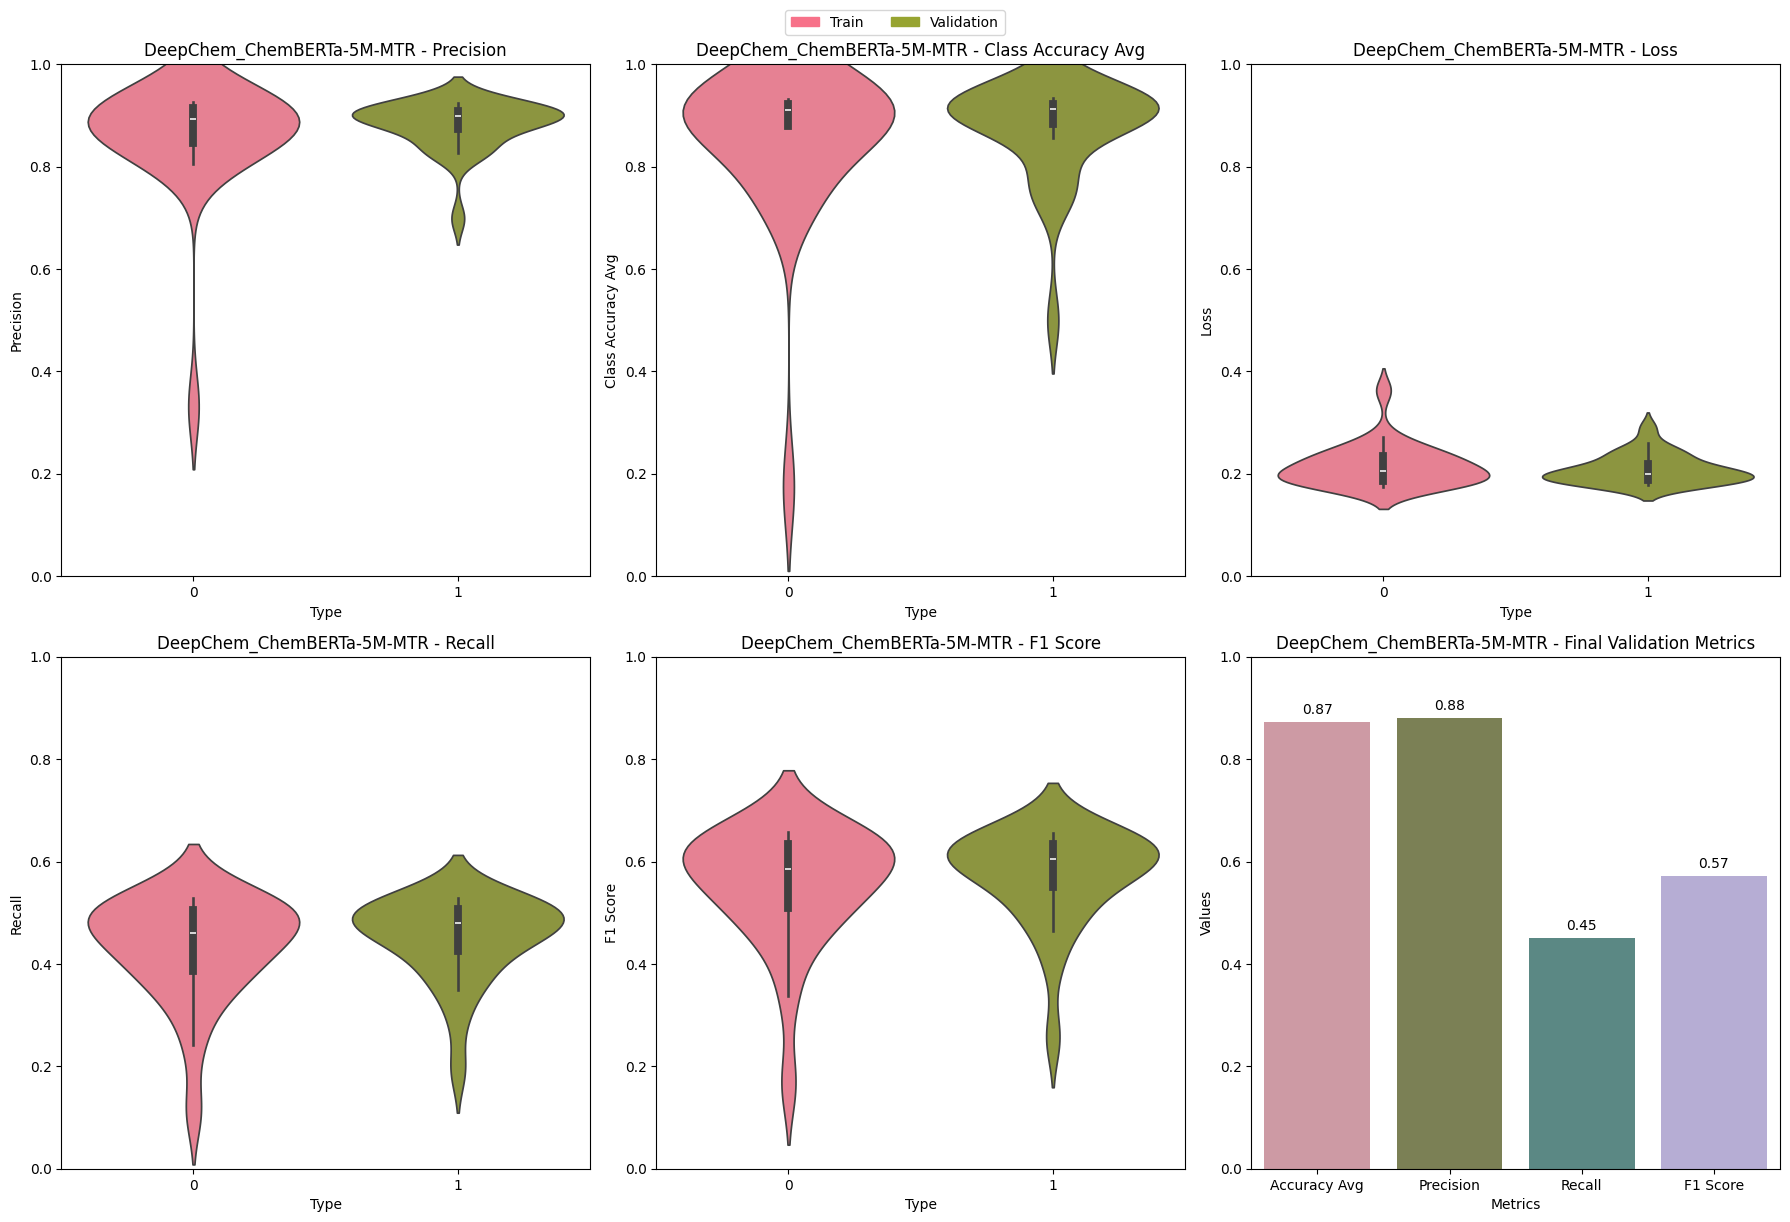


Model: DeepChem_ChemBERTa-10M-MLM
Best Parameters: {'learning_rate': 2.2191627639527453e-05, 'epochs': 4}
Final Validation Loss: 0.1628655771512349
Final Validation Class Avg Accuracy: 0.8988909437777645
Final Validation Precision: 0.904089594785401
Final Validation Recall: 0.4920664492636411
Final Validation F1 Score: 0.6177570095276085


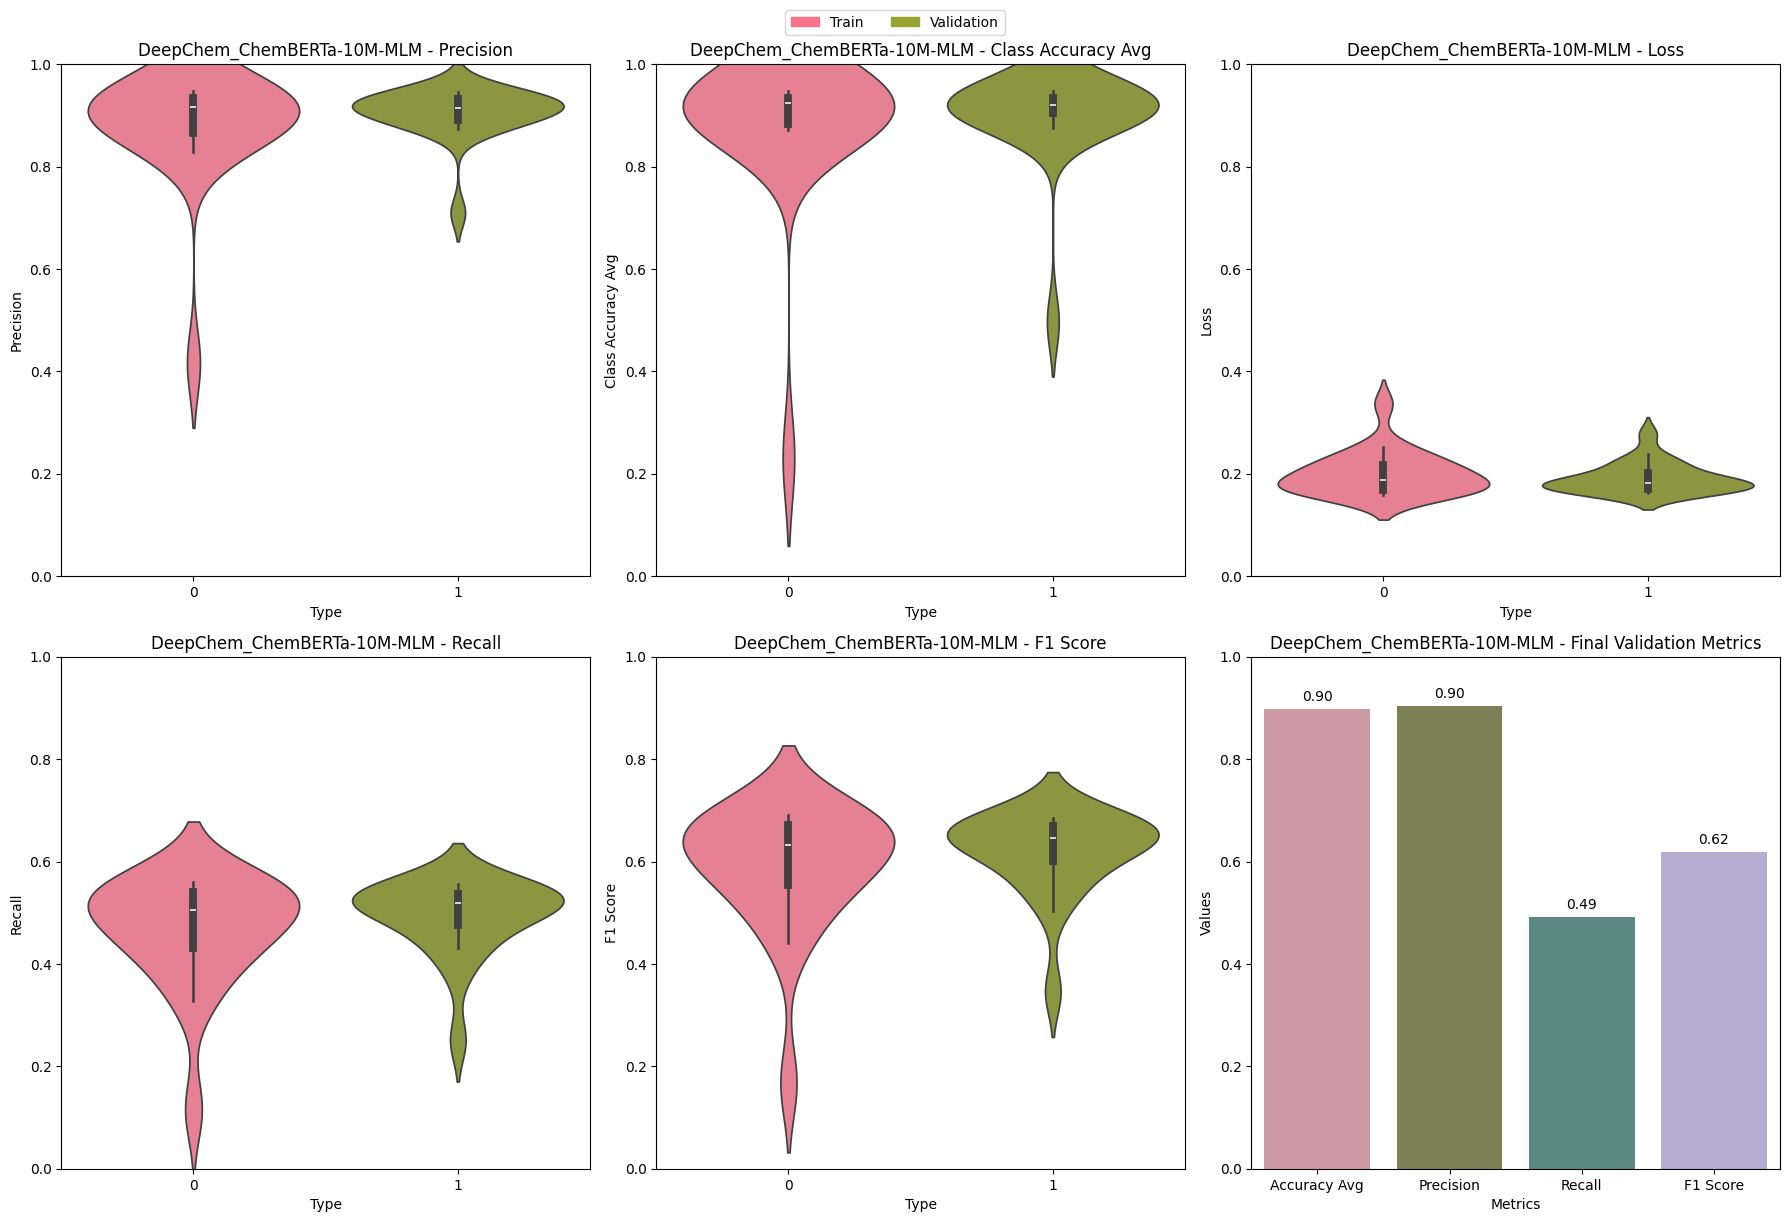


Model: DeepChem_ChemBERTa-10M-MTR
Best Parameters: {'learning_rate': 2.1213069455291102e-05, 'epochs': 5}
Final Validation Loss: 0.16920020588312842
Final Validation Class Avg Accuracy: 0.8938676000718214
Final Validation Precision: 0.8937582673614909
Final Validation Recall: 0.4815421465220841
Final Validation F1 Score: 0.6066975397818198


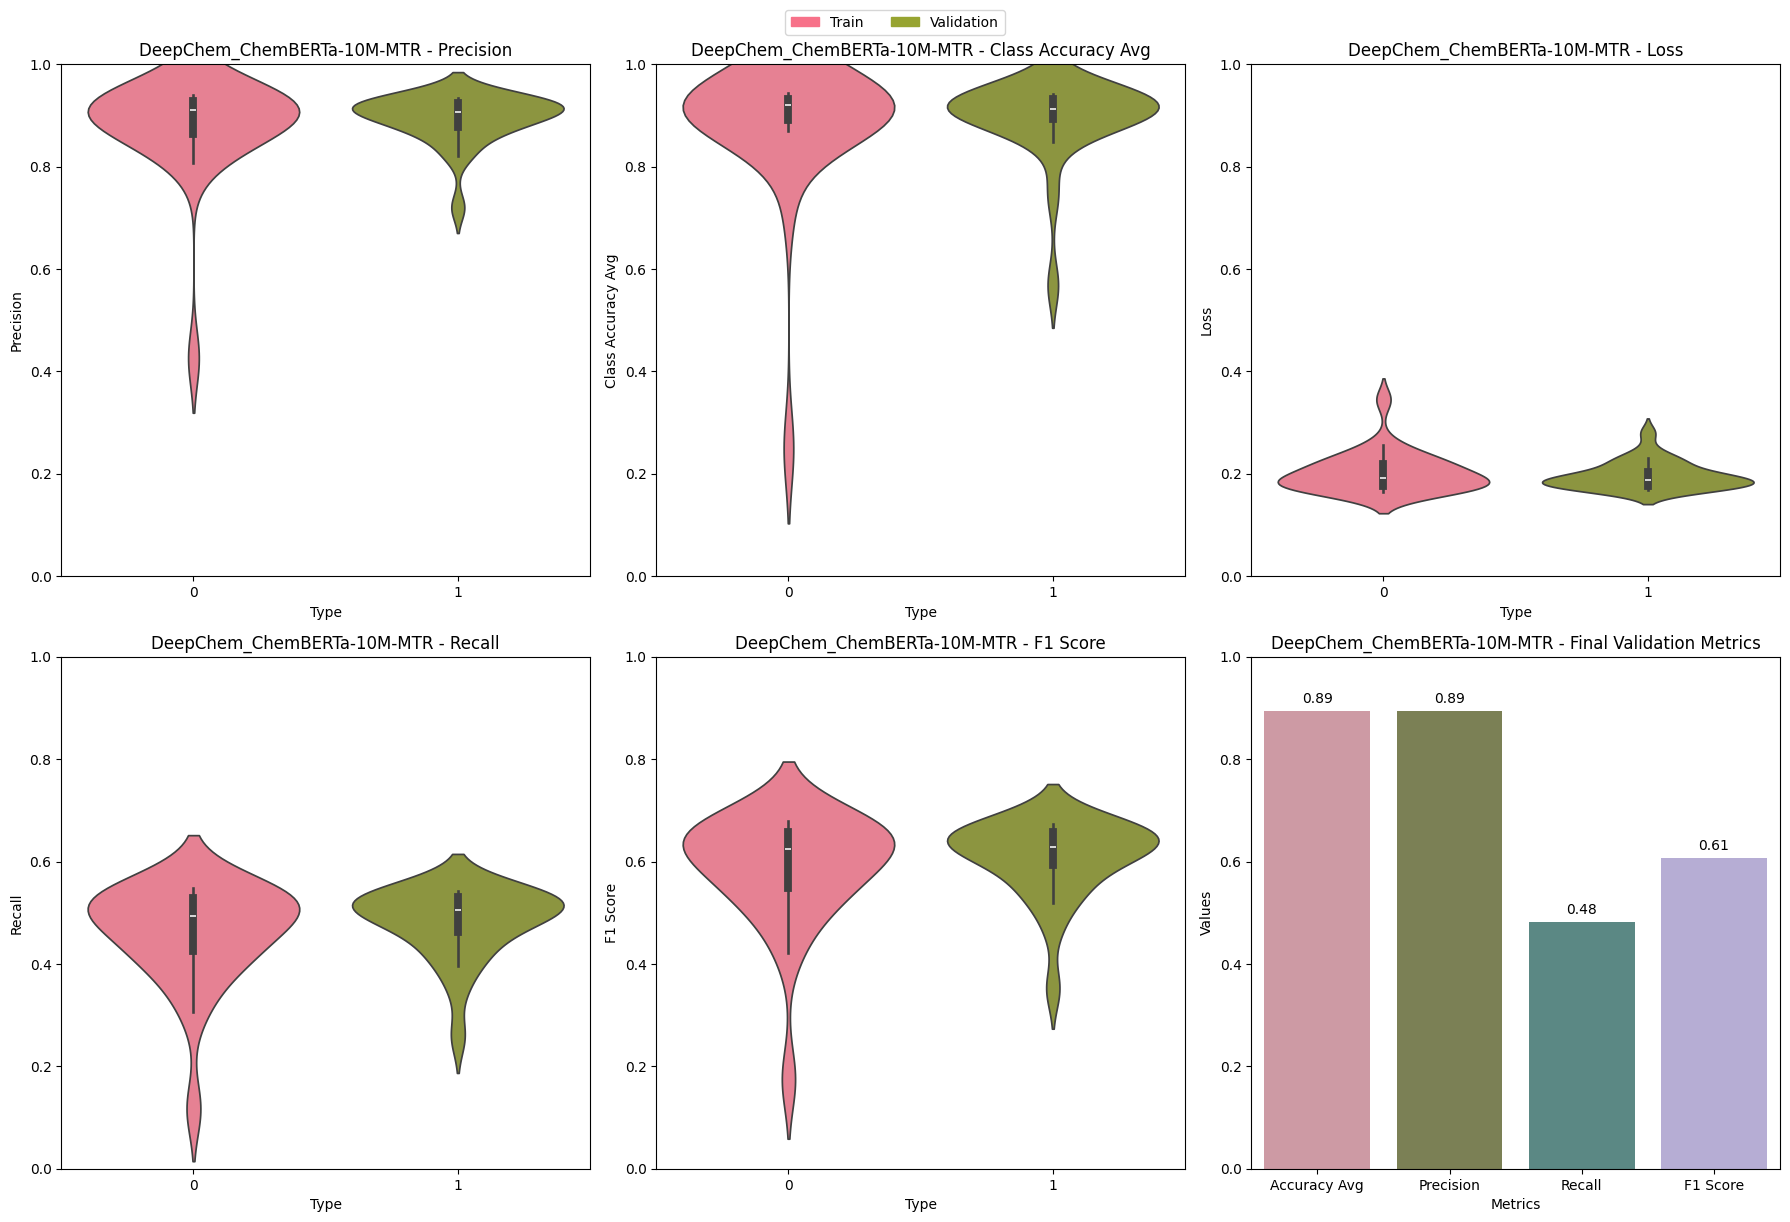


Model: DeepChem_ChemBERTa-77M-MTR
Best Parameters: {'learning_rate': 2.7656414064751142e-05, 'epochs': 5}
Final Validation Loss: 0.1690014365035264
Final Validation Class Avg Accuracy: 0.9034829089581088
Final Validation Precision: 0.902396738396118
Final Validation Recall: 0.4757032392079228
Final Validation F1 Score: 0.6030426043009549


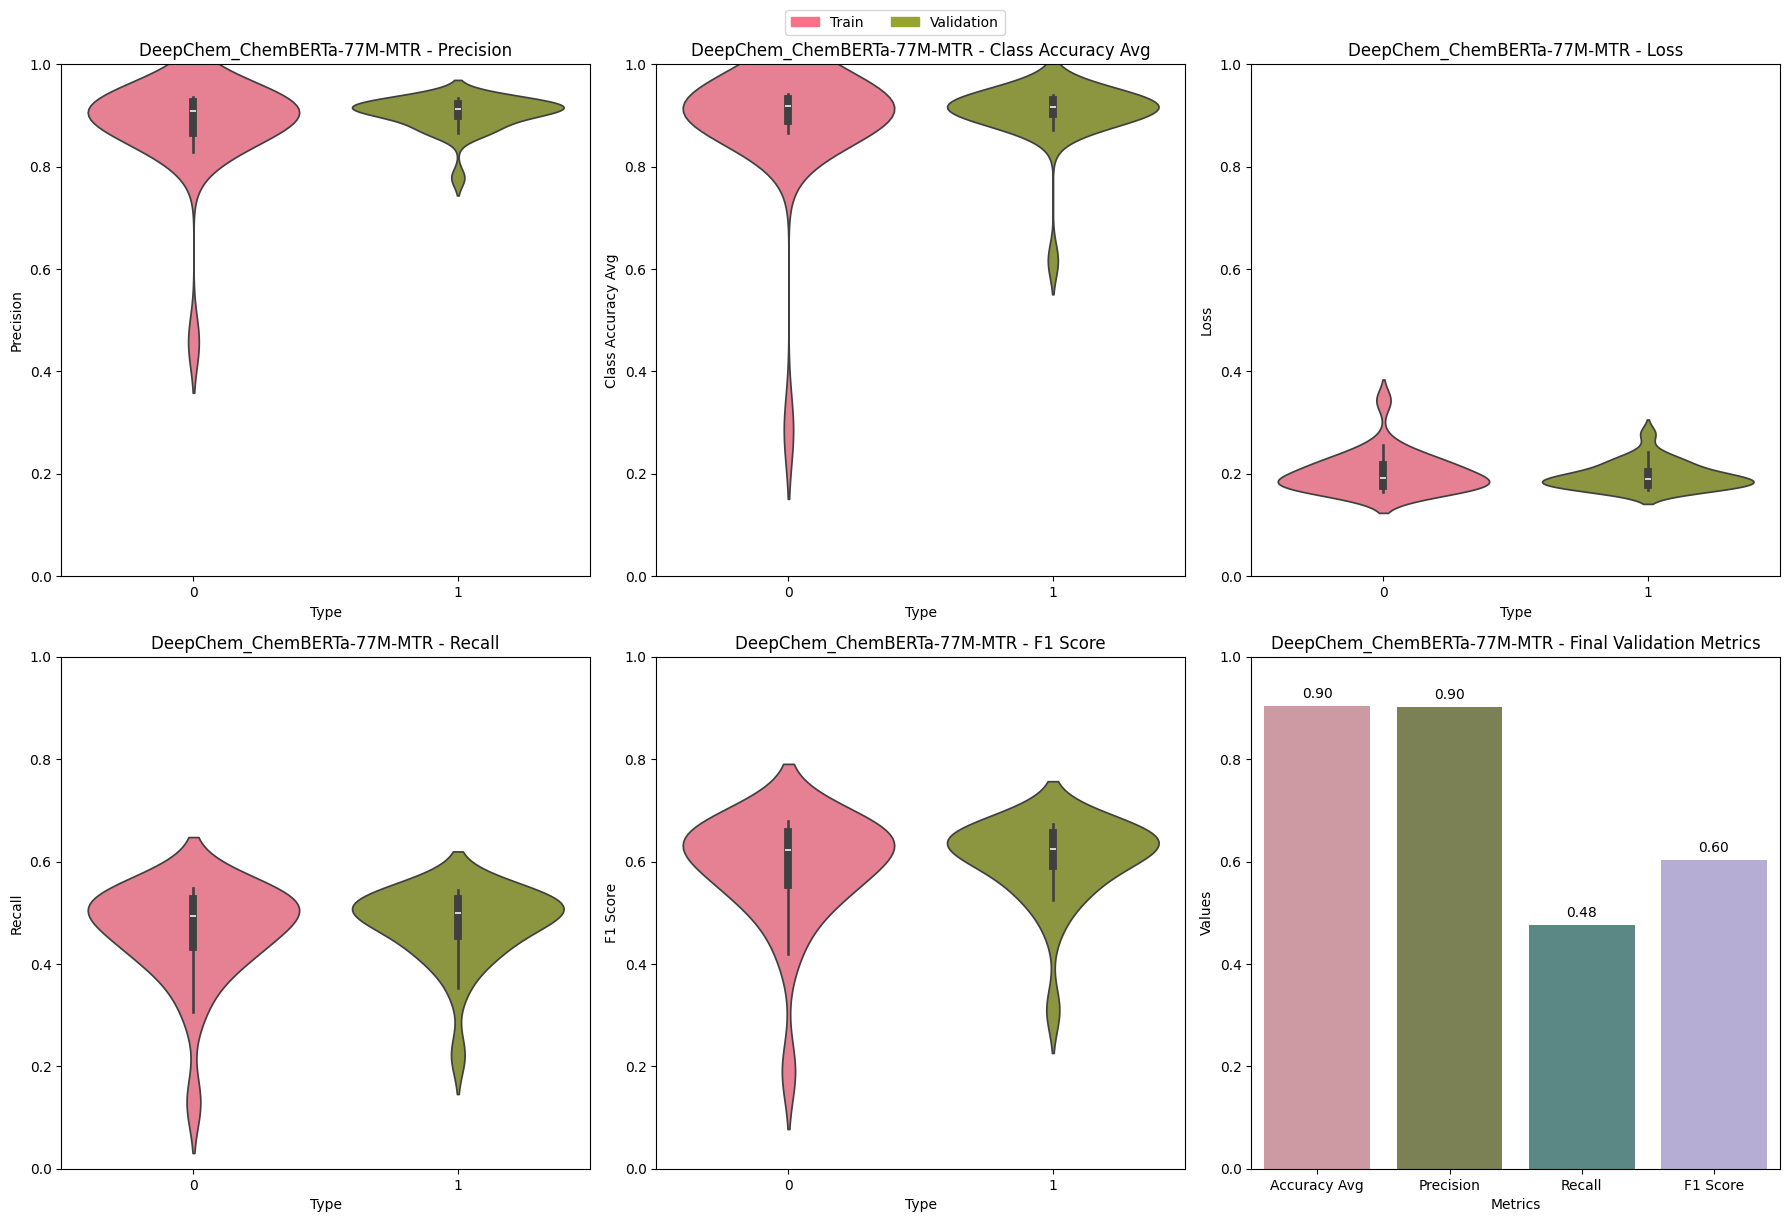


Model: DeepChem_ChemBERTa-77M-MTR
Best Parameters: {'learning_rate': 2.7656414064751142e-05, 'epochs': 5}
Final Validation Loss: 0.1690014365035264
Final Validation Class Avg Accuracy: 0.9034829089581088
Final Validation Precision: 0.902396738396118
Final Validation Recall: 0.4757032392079228
Final Validation F1 Score: 0.6030426043009549


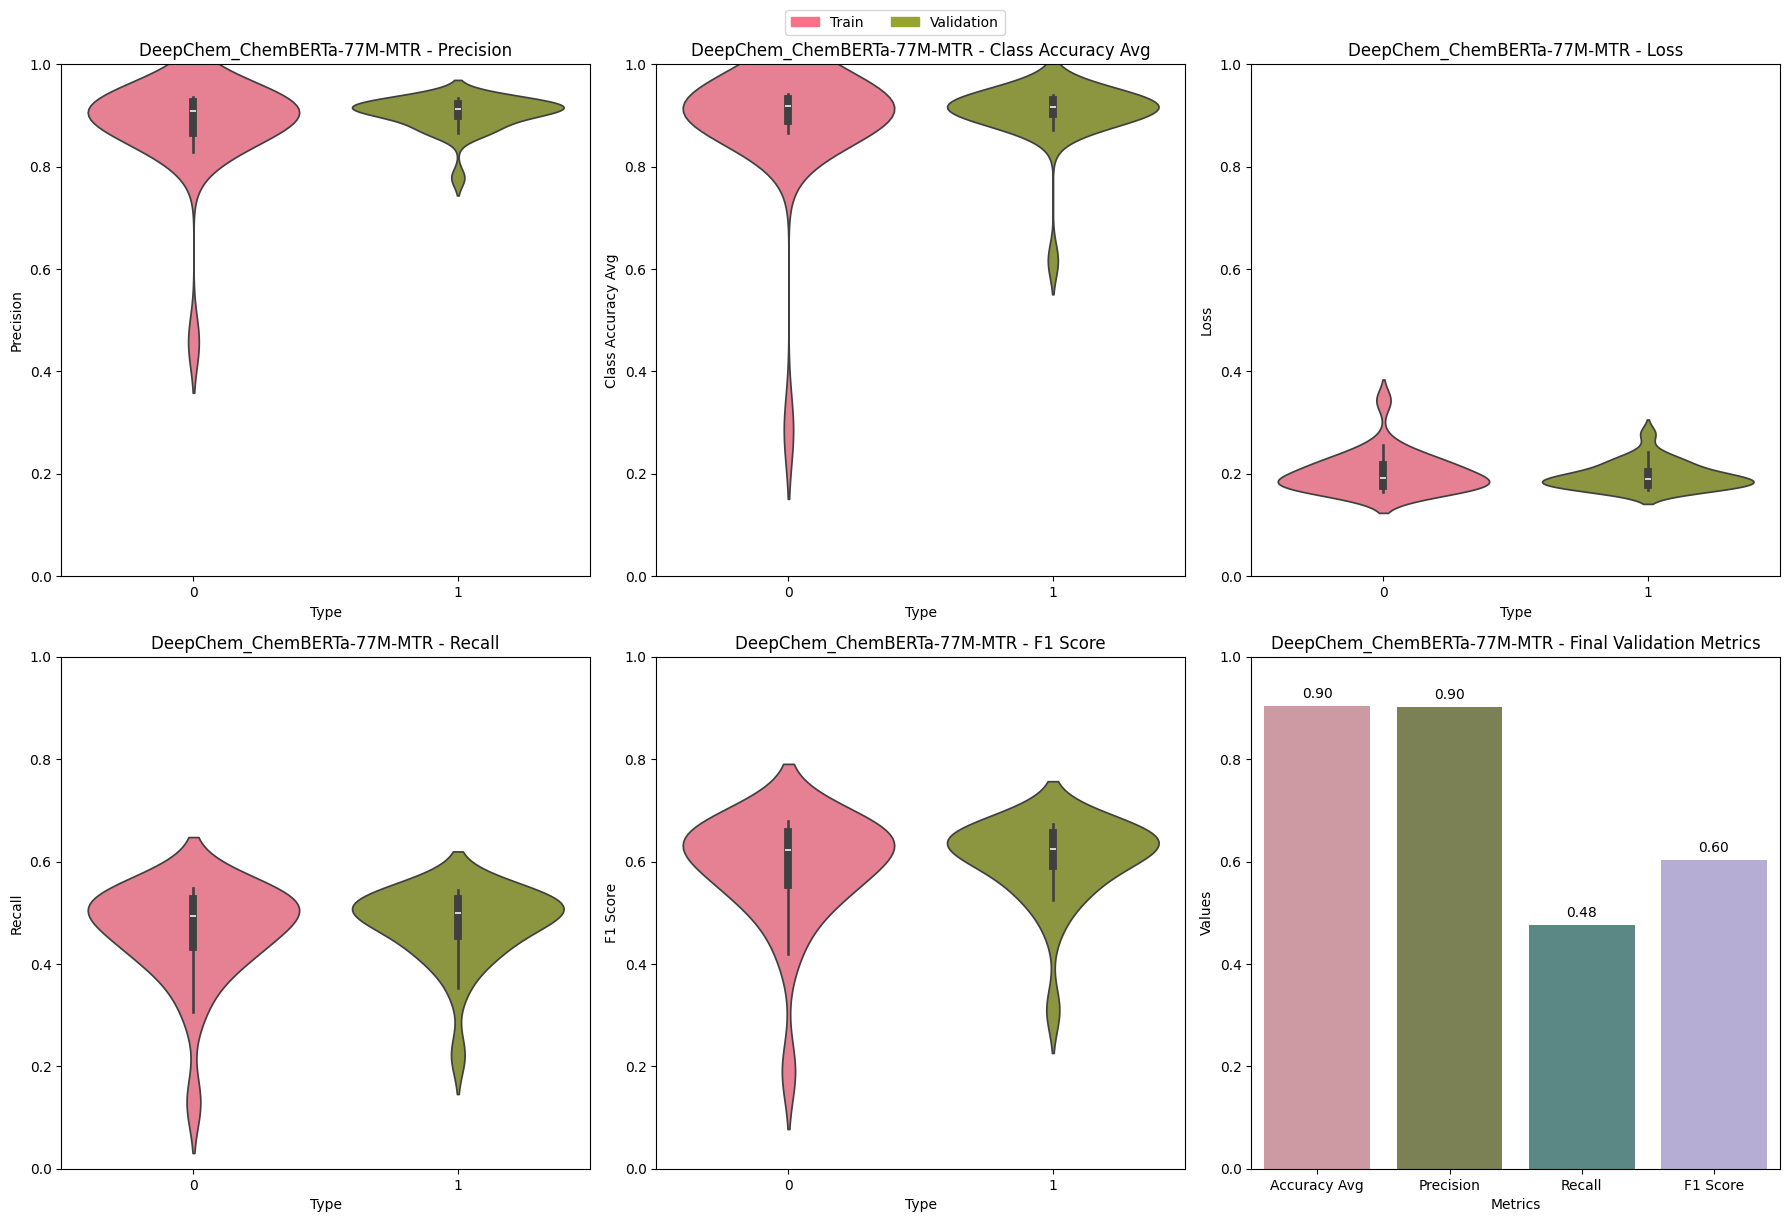


Consolidated report saved as 'consolidated_report.json'


In [39]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import pandas as pd

class VisualizePreTrainedLLMResults:
    def __init__(self, json_files, batch_size=1000):
        self.json_files = json_files
        self.batch_size = batch_size

    def load_metrics_in_batches(self, file_path):
        with open(file_path, 'r') as f:
            data = json.load(f)

        metrics = data['epoch_metrics']
        best_params = data['best_params']
        for i in range(0, len(metrics), self.batch_size):
            yield metrics[i:i+self.batch_size], best_params

    def analyze_metrics(self, metrics, best_params, model_name):
        # Verificar se metrics é uma lista de dicionários
        if not all(isinstance(m, dict) for m in metrics):
            raise ValueError("Metrics data is not in the expected format")

        epochs = []
        train_losses = []
        val_losses = []
        train_accuracies = []
        val_accuracies = []
        train_precisions = []
        val_precisions = []
        train_recalls = []
        val_recalls = []
        train_f1s = []
        val_f1s = []
        train_class_avg_accuracies = []
        val_class_avg_accuracies = []
        roc_aucs = []
        pr_aucs = []

        for m in metrics:
            epochs.append(m['epoch'])
            train_losses.append(m['train_loss'])
            val_losses.append(m['val_loss'])
            train_accuracies.append(m['train_accuracy'])
            val_accuracies.append(m['val_accuracy'])
            train_precisions.append(m['train_precision'])
            val_precisions.append(m['val_precision'])
            train_recalls.append(m['train_recall'])
            val_recalls.append(m['val_recall'])
            train_f1s.append(m['train_f1'])
            val_f1s.append(m['val_f1'])
            train_class_avg_accuracies.append(m['train_class_avg_accuracy'])
            val_class_avg_accuracies.append(m['val_class_avg_accuracy'])
            roc_aucs.append(m['roc_auc'])
            pr_aucs.append(m['pr_auc'])

        model_display_name = model_name.split('/')[-1]

        # Calculate the average final metrics
        final_val_class_avg_accuracy = np.mean(val_class_avg_accuracies)
        final_val_precision = np.mean(val_precisions)
        final_val_recall = np.mean(val_recalls)
        final_val_f1 = np.mean(val_f1s)
        final_val_roc_auc = np.mean(roc_aucs)
        final_val_pr_auc = np.mean(pr_aucs)

        print(f"\nModel: {model_display_name}")
        print(f"Best Parameters: {best_params}")
        print(f"Final Validation Loss: {val_losses[-1]}")
        print(f"Final Validation Class Avg Accuracy: {final_val_class_avg_accuracy}")
        print(f"Final Validation Precision: {final_val_precision}")
        print(f"Final Validation Recall: {final_val_recall}")
        print(f"Final Validation F1 Score: {final_val_f1}")

        plt.figure(figsize=(18, 12))

        colors = sns.color_palette("husl", 4)  # Four colors for train, validation, test, and ROC/PR AUC
        final_colors = sns.color_palette("husl", 4, desat=0.5)  # Distinct colors for final metrics

        plt.subplot(2, 3, 1)
        sns.violinplot(data=[train_precisions, val_precisions], palette=colors[:2])
        plt.xlabel('Type')
        plt.ylabel('Precision')
        plt.title(f'{model_display_name} - Precision')
        plt.ylim(0, 1)

        plt.subplot(2, 3, 2)
        sns.violinplot(data=[train_class_avg_accuracies, val_class_avg_accuracies], palette=colors[:2])
        plt.xlabel('Type')
        plt.ylabel('Class Accuracy Avg')
        plt.title(f'{model_display_name} - Class Accuracy Avg')
        plt.ylim(0, 1)

        plt.subplot(2, 3, 3)
        sns.violinplot(data=[train_losses, val_losses], palette=colors[:2])
        plt.xlabel('Type')
        plt.ylabel('Loss')
        plt.title(f'{model_display_name} - Loss')
        plt.ylim(0, 1)

        plt.subplot(2, 3, 4)
        sns.violinplot(data=[train_recalls, val_recalls], palette=colors[:2])
        plt.xlabel('Type')
        plt.ylabel('Recall')
        plt.title(f'{model_display_name} - Recall')
        plt.ylim(0, 1)

        plt.subplot(2, 3, 5)
        sns.violinplot(data=[train_f1s, val_f1s], palette=colors[:2])
        plt.xlabel('Type')
        plt.ylabel('F1 Score')
        plt.title(f'{model_display_name} - F1 Score')
        plt.ylim(0, 1)

        plt.subplot(2, 3, 6)
        metrics_names = ['Accuracy Avg', 'Precision', 'Recall', 'F1 Score']
        final_metrics = [final_val_class_avg_accuracy, final_val_precision, final_val_recall, final_val_f1]
        final_metrics_df = pd.DataFrame({'Metrics': metrics_names, 'Values': final_metrics, 'Hue': metrics_names})
        sns.barplot(x='Metrics', y='Values', hue='Hue', data=final_metrics_df, palette=final_colors, dodge=False, legend=False)
        plt.xlabel('Metrics')
        plt.ylabel('Values')
        plt.title(f'{model_display_name} - Final Validation Metrics')
        plt.ylim(0, 1)
        for i, v in enumerate(final_metrics):
            plt.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom')

        # Overall legend
        legend_handles = [Patch(color=colors[0], label='Train'), Patch(color=colors[1], label='Validation')]
        plt.figlegend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2)

        plt.tight_layout()
        plt.savefig(f'{model_display_name}_metrics.png')
        plt.show()

    def run_analysis(self):
        metrics_data = []

        for file in self.json_files:
            file_path = os.path.join('./', file)
            if os.path.exists(file_path):
                all_metrics = []
                model_name = file.split('metrics_')[1].split('.json')[0]  # Get the full model name
                for batch, best_params in self.load_metrics_in_batches(file_path):
                    all_metrics.extend(batch)
                    self.analyze_metrics(batch, best_params, model_name)
                metrics_data.append((model_name, all_metrics, best_params))
            else:
                print(f"File {file_path} does not exist.")

        # Generate a consolidated report
        report = {
            model: {
                "best_params": best_params,
                "final_metrics": {
                    "val_loss": np.mean([m['val_loss'] for m in metrics]),
                    "class_avg_accuracy": np.mean([m['val_class_avg_accuracy'] for m in metrics]),
                    "precision": np.mean([m['val_precision'] for m in metrics]),
                    "recall": np.mean([m['val_recall'] for m in metrics]),
                    "f1": np.mean([m['val_f1'] for m in metrics]),
                    "roc_auc": np.mean([m['roc_auc'] for m in metrics]),
                    "pr_auc": np.mean([m['pr_auc'] for m in metrics])
                }
            }
            for model, metrics, best_params in metrics_data
        }

        with open('consolidated_report.json', 'w') as f:
            json.dump(report, f, indent=4)

        print("\nConsolidated report saved as 'consolidated_report.json'")


if __name__ == "__main__":
    json_files = [

        'metrics_DeepChem_SmilesTokenizer_PubChem_1M.json',
        'metrics_DeepChem_ChemBERTa-5M-MLM.json',
        'metrics_DeepChem_ChemBERTa-5M-MTR.json',
        'metrics_DeepChem_ChemBERTa-10M-MLM.json',
        'metrics_DeepChem_ChemBERTa-10M-MTR.json',
        'metrics_DeepChem_ChemBERTa-77M-MTR.json',
        'metrics_DeepChem_ChemBERTa-77M-MTR.json'
    ]
    visualizer = VisualizePreTrainedLLMResults(json_files)
    visualizer.run_analysis()


Train Distribution:
{'Total samples': 288169, 'Label distribution': {'CMGC': 19.84321700113475, 'CAMK': 12.881330052850931, 'AGC': 13.275543170847662, 'Transferase': 8.497444208086227, 'Tyrosine': 30.04486950365931, 'TKL': 7.6566181650351, 'CK1': 1.6521555059704547, 'STE': 5.7573854231371175, 'Serine': 0.3914369692784443}}

Test Distribution:
{'Total samples': 72043, 'Label distribution': {'Tyrosine': 29.88770595338895, 'AGC': 13.305942284468998, 'CAMK': 13.104673597712477, 'Transferase': 8.457449023499853, 'STE': 5.777105339866469, 'CMGC': 19.838152214649586, 'TKL': 7.585747400857821, 'CK1': 1.6365226323168107, 'Serine': 0.4067015532390378}}

Model: DeepChem_SmilesTokenizer_PubChem_1M
Best Parameters: {'learning_rate': 2.3037814094199713e-05, 'epochs': 5}
Mean ROC AUC: 0.8152448877603035
Mean PR AUC: 0.48597130619322343
Confusion Matrix:
[[165237  33995]
 [ 14869 146111]]


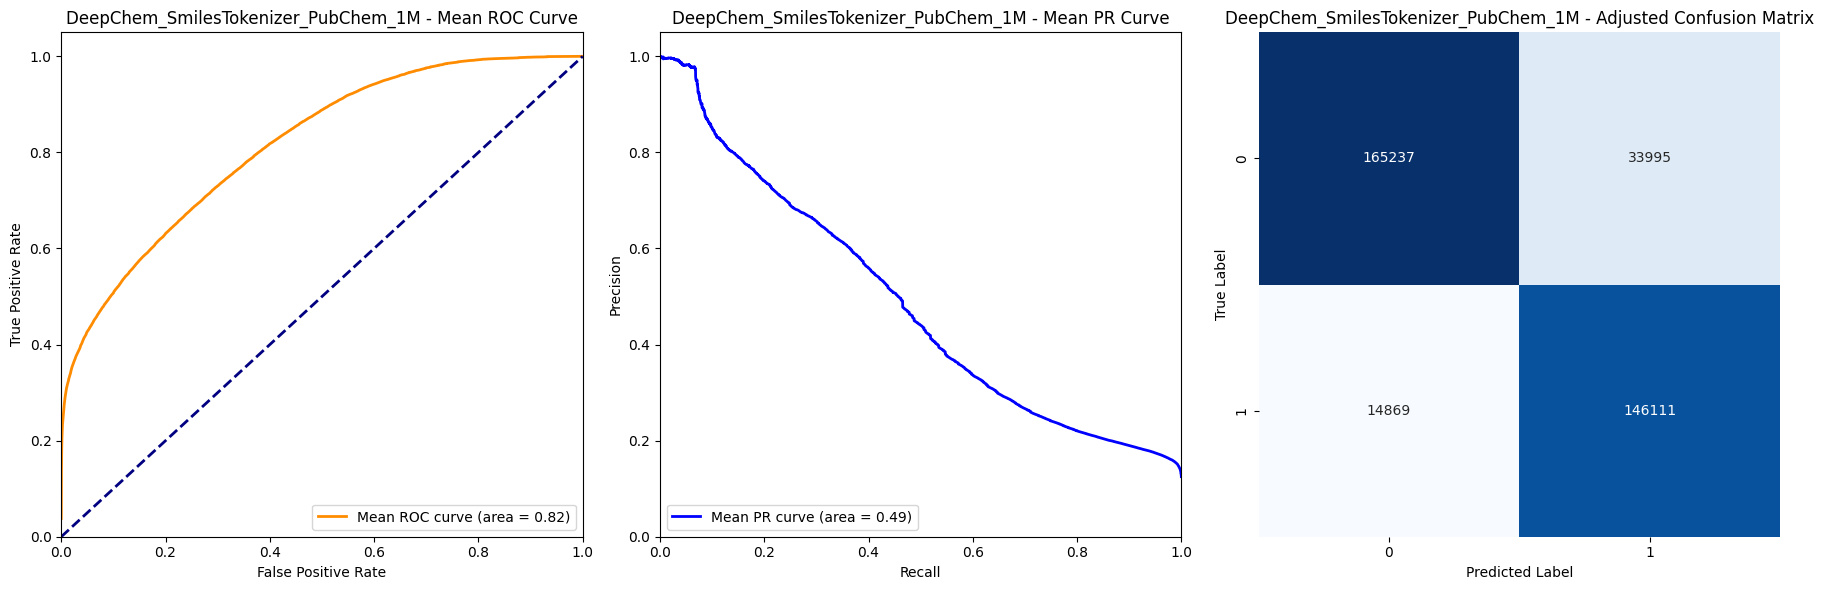


Model: DeepChem_ChemBERTa-5M-MLM
Best Parameters: {'learning_rate': 2.708507991367365e-05, 'epochs': 5}
Mean ROC AUC: 0.7992795877197204
Mean PR AUC: 0.4727039766811357
Confusion Matrix:
[[164555  29429]
 [ 15551 150677]]


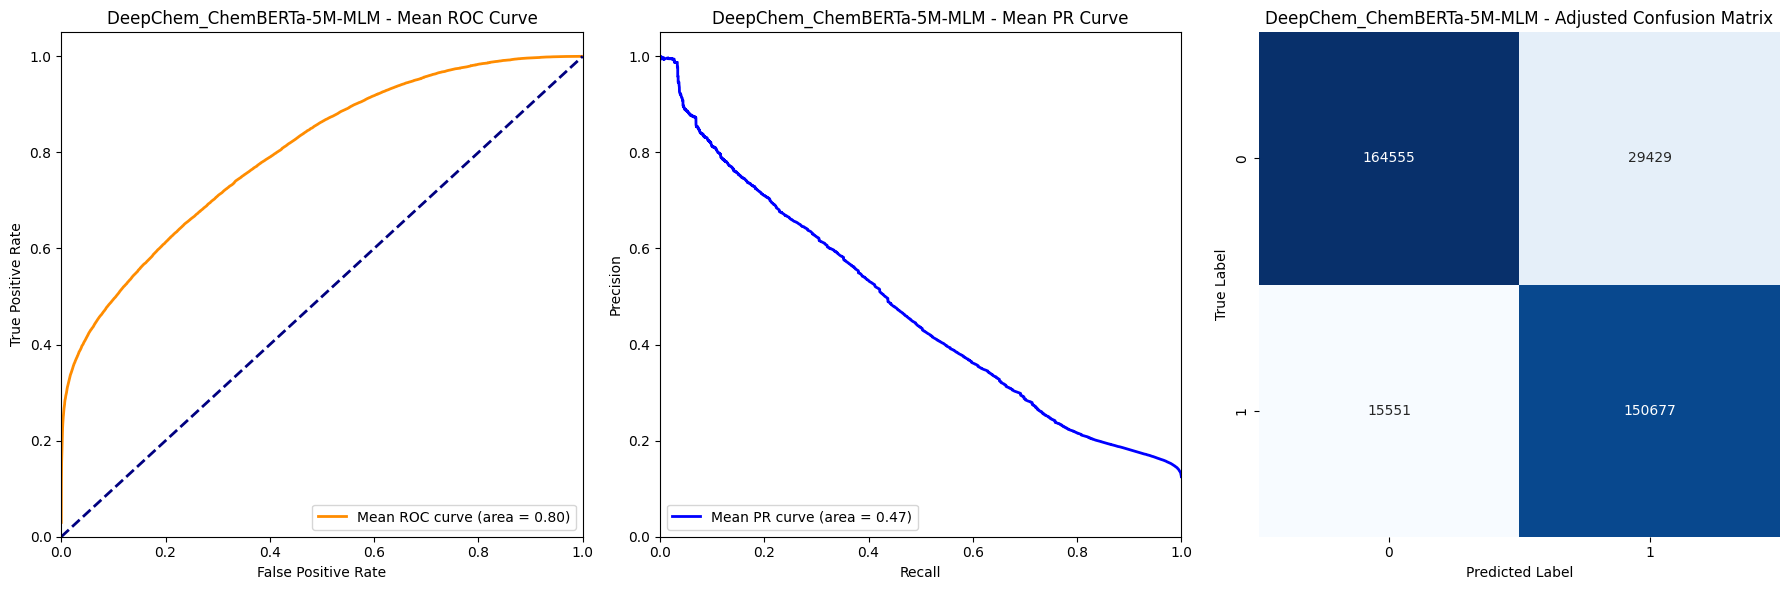


Model: DeepChem_ChemBERTa-5M-MTR
Best Parameters: {'learning_rate': 1.0385069023932177e-05, 'epochs': 5}
Mean ROC AUC: 0.7436289150672724
Mean PR AUC: 0.3522797478393125
Confusion Matrix:
[[162189  42487]
 [ 17917 137619]]


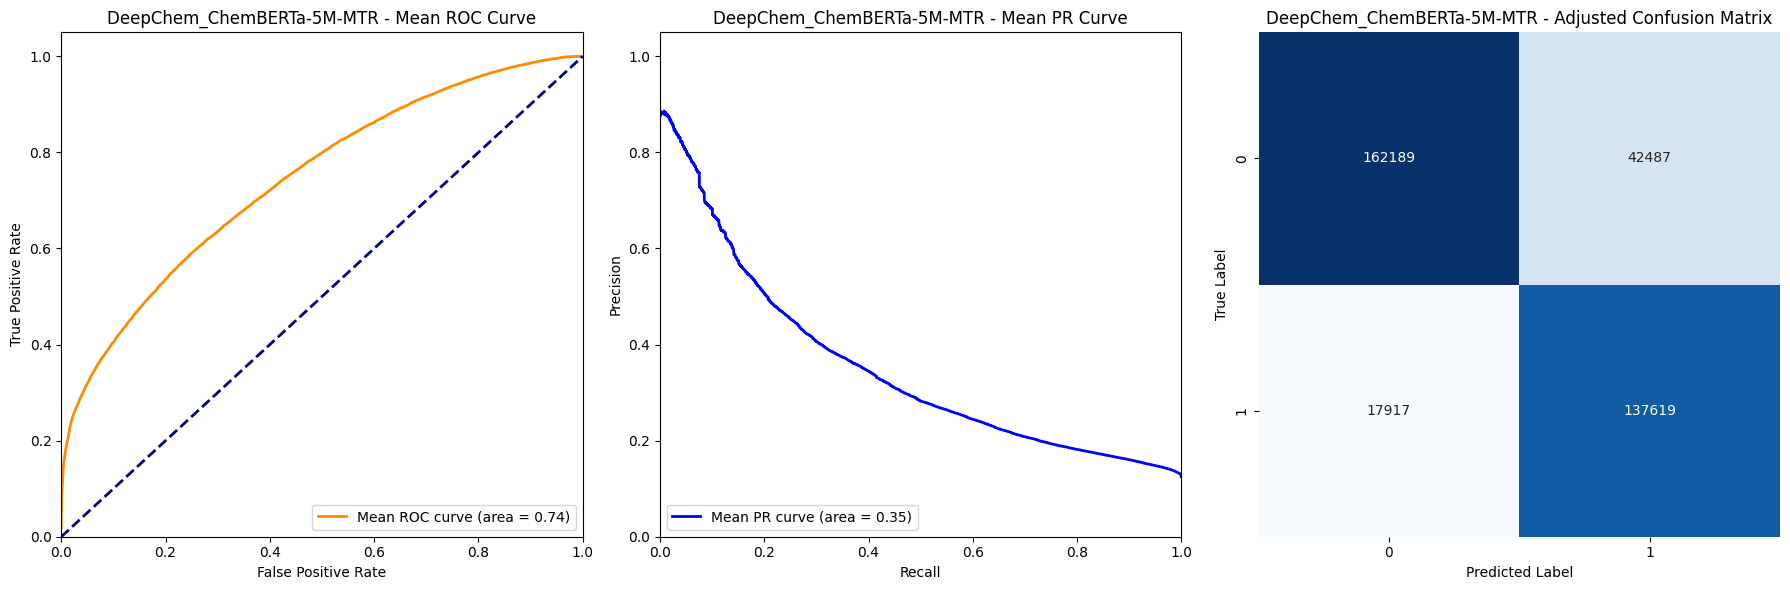


Model: DeepChem_ChemBERTa-10M-MLM
Best Parameters: {'learning_rate': 2.2191627639527453e-05, 'epochs': 4}
Mean ROC AUC: 0.7657521218521636
Mean PR AUC: 0.40730828039763683
Confusion Matrix:
[[163684  32870]
 [ 16422 147236]]


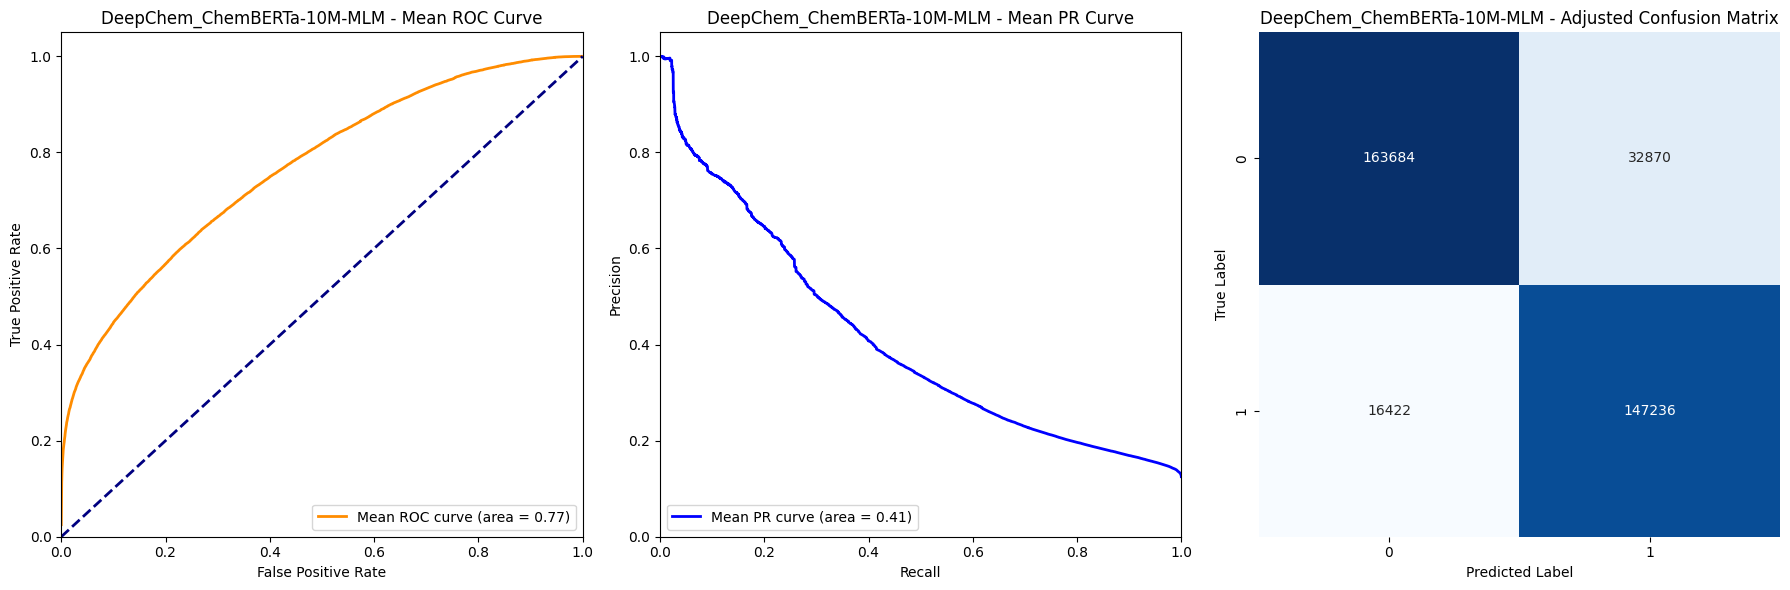


Model: DeepChem_ChemBERTa-10M-MTR
Best Parameters: {'learning_rate': 2.1213069455291102e-05, 'epochs': 5}
Mean ROC AUC: 0.766244444501988
Mean PR AUC: 0.40374449011637276
Confusion Matrix:
[[163501  40252]
 [ 16605 139854]]


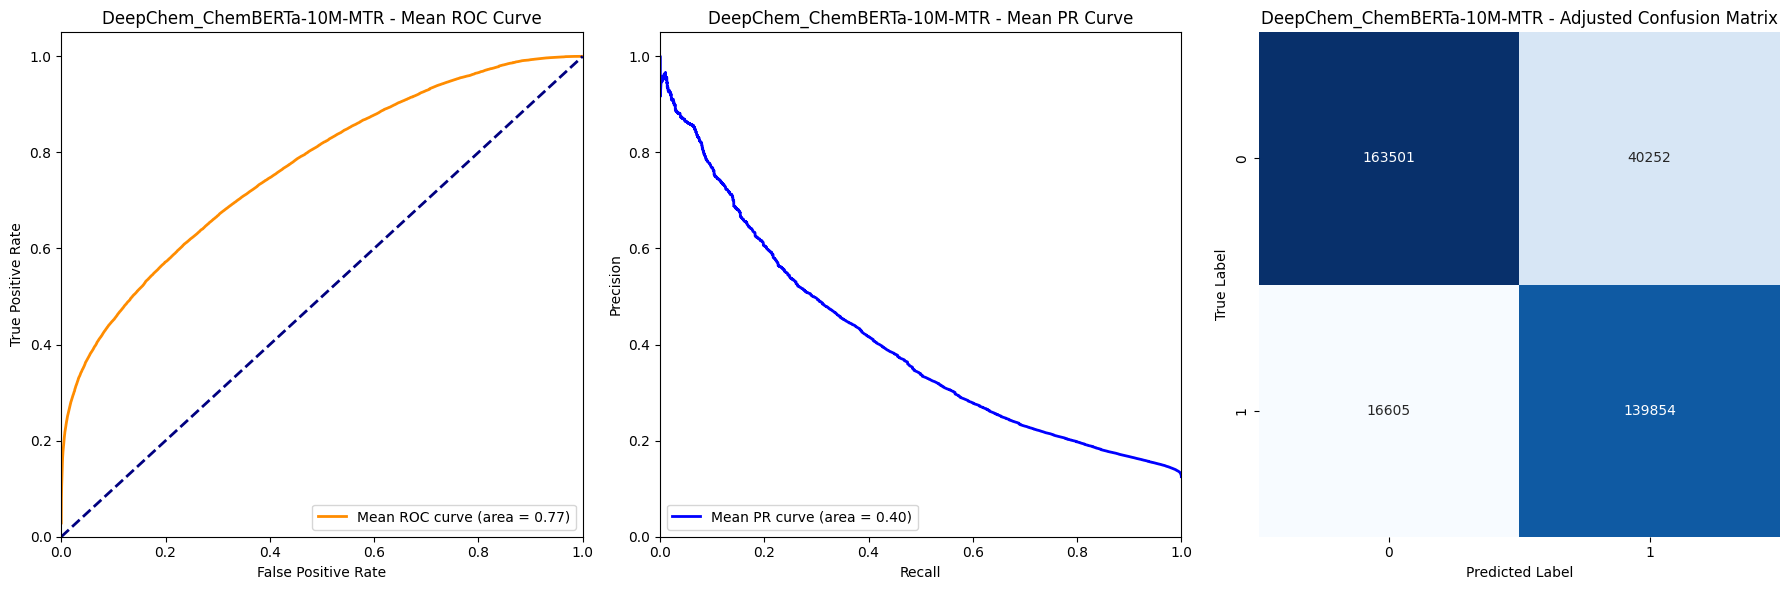


Model: DeepChem_ChemBERTa-77M-MTR
Best Parameters: {'learning_rate': 2.7656414064751142e-05, 'epochs': 5}
Mean ROC AUC: 0.7721576772463085
Mean PR AUC: 0.404598470026333
Confusion Matrix:
[[163084  33353]
 [ 17022 146753]]


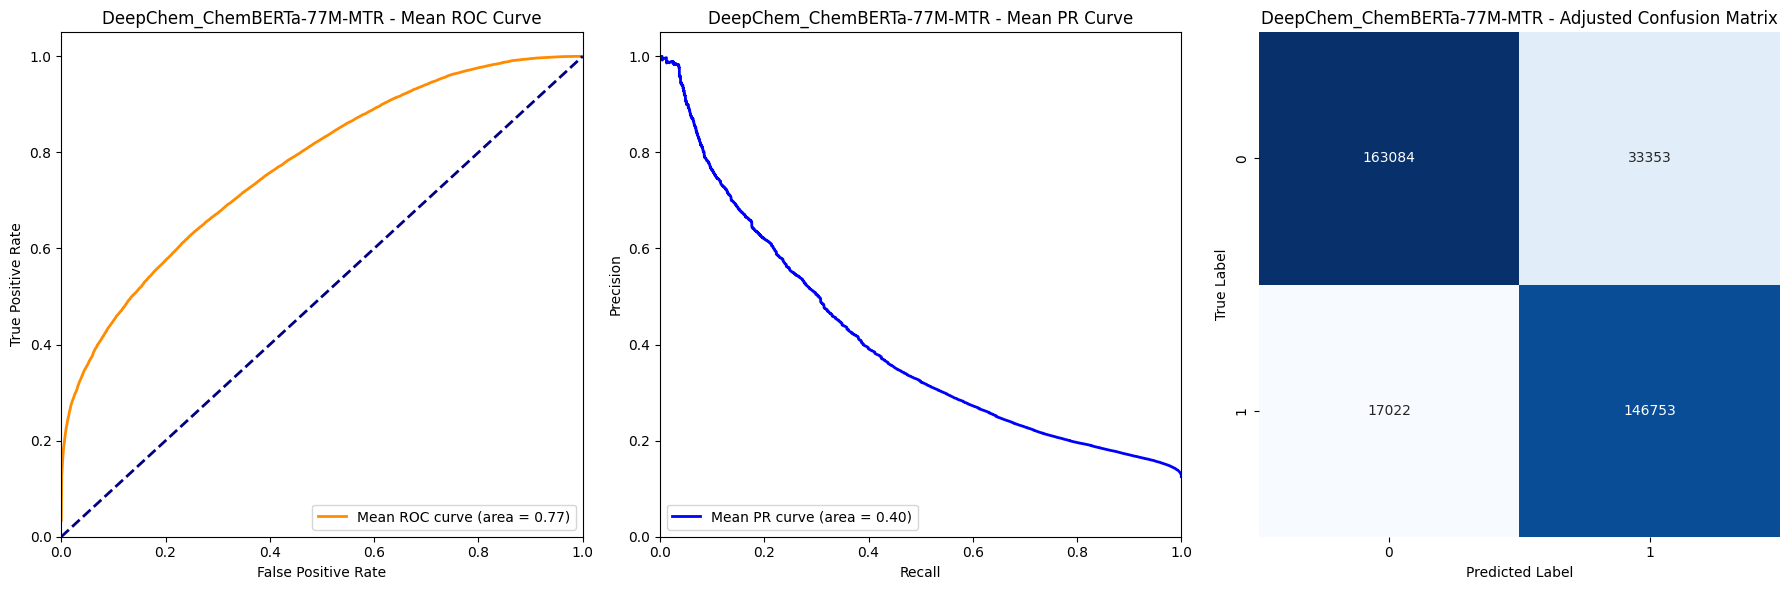

File ./metrics_DeepChem_ChemBERTa-77M-MLM.json does not exist.

Model: DeepChem_ChemBERTa-77M-MTR
Best Parameters: {'learning_rate': 2.7656414064751142e-05, 'epochs': 5}
Mean ROC AUC: 0.7721576772463085
Mean PR AUC: 0.404598470026333
Confusion Matrix:
[[163084  33353]
 [ 17022 146753]]


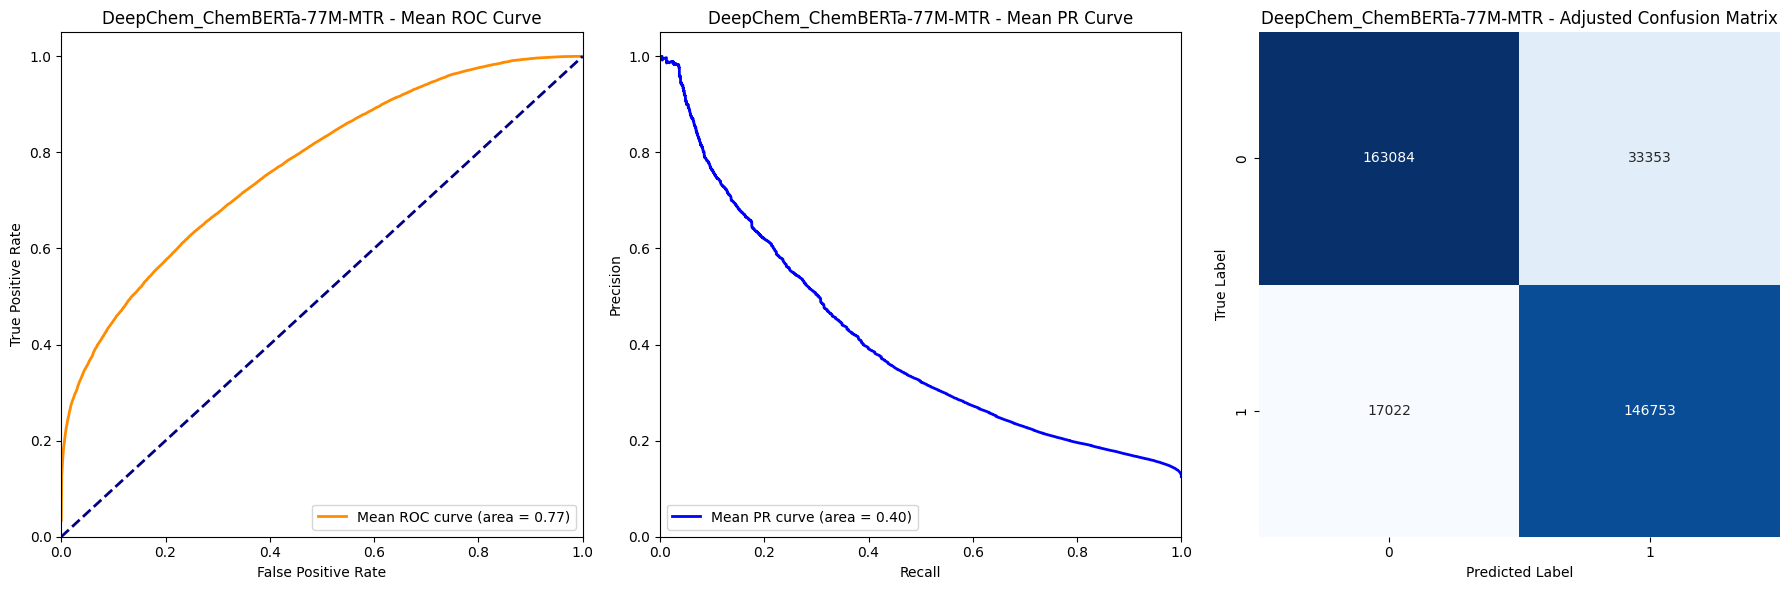


Consolidated report saved as 'consolidated_report.json'


In [38]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
import pandas as pd
from collections import Counter

class VisualizePreTrainedLLMResults:
    def __init__(self, json_files, batch_size=1000):
        self.json_files = json_files
        self.batch_size = batch_size

    def load_metrics_in_batches(self, file_path):
        with open(file_path, 'r') as f:
            data = json.load(f)

        metrics = data['epoch_metrics']
        best_params = data['best_params']
        for i in range(0, len(metrics), self.batch_size):
            yield metrics[i:i+self.batch_size], best_params

    def check_distribution(self, labels):
        # Contar as ocorrências de cada label
        label_counts = Counter(labels)

        # Calcular a distribuição
        total_samples = sum(label_counts.values())
        distribution = {label: count / total_samples * 100 for label, count in label_counts.items()}

        return {
            'Total samples': total_samples,
            'Label distribution': distribution
        }

    def save_molecules_by_confusion_matrix(self, val_labels, val_probabilities, smiles, output_dir):
        tp_molecules = []
        fp_molecules = []
        tn_molecules = []
        fn_molecules = []

        num_labels = val_labels.shape[1]
        num_samples = val_labels.shape[0]

        for i in range(num_labels):
            for j in range(num_samples):
                true_label = val_labels[j, i]
                predicted_label = (val_probabilities[j, i] > 0.5).astype(int)
                molecule = smiles[j]

                if true_label == 1 and predicted_label == 1:
                    tp_molecules.append(molecule)
                elif true_label == 0 and predicted_label == 1:
                    fp_molecules.append(molecule)
                elif true_label == 0 and predicted_label == 0:
                    tn_molecules.append(molecule)
                elif true_label == 1 and predicted_label == 0:
                    fn_molecules.append(molecule)

        os.makedirs(output_dir, exist_ok=True)

        with open(os.path.join(output_dir, 'true_positive.tsv'), 'w') as f:
            for mol in tp_molecules:
                f.write(mol + '\n')

        with open(os.path.join(output_dir, 'false_positive.tsv'), 'w') as f:
            for mol in fp_molecules:
                f.write(mol + '\n')

        with open(os.path.join(output_dir, 'true_negative.tsv'), 'w') as f:
            for mol in tn_molecules:
                f.write(mol + '\n')

        with open(os.path.join(output_dir, 'false_negative.tsv'), 'w') as f:
            for mol in fn_molecules:
                f.write(mol + '\n')

    def analyze_metrics(self, metrics, best_params, model_name, num_samples, smiles):
        # Verificar se metrics é uma lista de dicionários
        if not all(isinstance(m, dict) for m in metrics):
            raise ValueError("Metrics data is not in the expected format")

        val_probabilities = []
        val_labels = []
        for m in metrics:
            val_probabilities.extend(m['val_probabilities'])
            val_labels.extend(m['val_labels'])

        model_display_name = model_name.split('/')[-1]

        # Convertendo listas para arrays numpy
        val_probabilities = np.array(val_probabilities)
        val_labels = np.array(val_labels)

        # Ajustar os tamanhos se necessário
        if val_labels.shape[0] > len(smiles):
            val_labels = val_labels[:len(smiles)]
            val_probabilities = val_probabilities[:len(smiles)]
        elif val_labels.shape[0] < len(smiles):
            smiles = smiles[:val_labels.shape[0]]

        if val_labels.shape[0] != len(smiles):
            raise ValueError("The number of smiles does not match the number of validation labels.")

        # Inicializar variáveis para calcular a média das curvas ROC e PR
        fpr_dict = {}
        tpr_dict = {}
        roc_auc_dict = {}
        precision_dict = {}
        recall_dict = {}
        pr_auc_dict = {}

        for i in range(val_labels.shape[1]):
            fpr_dict[i], tpr_dict[i], _ = roc_curve(val_labels[:, i], val_probabilities[:, i])
            precision_dict[i], recall_dict[i], _ = precision_recall_curve(val_labels[:, i], val_probabilities[:, i])
            roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])
            pr_auc_dict[i] = auc(recall_dict[i], precision_dict[i])

        # Calcular a média das curvas ROC
        all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in fpr_dict]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in fpr_dict:
            mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
        mean_tpr /= len(fpr_dict)
        mean_roc_auc = auc(all_fpr, mean_tpr)

        # Calcular a média das curvas PR
        all_recall = np.unique(np.concatenate([recall_dict[i] for i in recall_dict]))
        mean_precision = np.zeros_like(all_recall)
        for i in recall_dict:
            mean_precision += np.interp(all_recall, recall_dict[i][::-1], precision_dict[i][::-1])
        mean_precision /= len(recall_dict)
        mean_pr_auc = auc(all_recall, mean_precision)

        # Calcular a matriz de confusão para cada classe e somá-las
        total_cm = np.zeros((2, 2))
        for i in range(val_labels.shape[1]):
            cm = confusion_matrix(val_labels[:, i], (val_probabilities[:, i] > 0.5).astype(int))
            if cm.shape == (2, 2):
                total_cm += cm

        # Normalizando a matriz de confusão para refletir o número total de moléculas analisadas
        total_samples = num_samples
        positive_samples = total_samples / 2
        negative_samples = total_samples / 2

        tp_fp_sum = total_cm[1, 1] + total_cm[0, 1]
        tn_fn_sum = total_cm[0, 0] + total_cm[1, 0]

        scaling_factor_tp_fp = positive_samples / tp_fp_sum
        scaling_factor_tn_fn = negative_samples / tn_fn_sum

        total_cm[1, 1] *= scaling_factor_tp_fp
        total_cm[0, 1] *= scaling_factor_tp_fp
        total_cm[0, 0] *= scaling_factor_tn_fn
        total_cm[1, 0] *= scaling_factor_tn_fn

        total_cm = np.round(total_cm).astype(int)

        print(f"\nModel: {model_display_name}")
        print(f"Best Parameters: {best_params}")
        print(f"Mean ROC AUC: {mean_roc_auc}")
        print(f"Mean PR AUC: {mean_pr_auc}")

        print("Confusion Matrix:")
        print(total_cm)

        plt.figure(figsize=(18, 6))

        # Plotando a média da curva ROC
        plt.subplot(1, 3, 1)
        plt.plot(all_fpr, mean_tpr, color='darkorange', lw=2, label=f'Mean ROC curve (area = {mean_roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{model_display_name} - Mean ROC Curve')
        plt.legend(loc="lower right")

        # Plotando a média da curva PR
        plt.subplot(1, 3, 2)
        plt.plot(all_recall, mean_precision, color='blue', lw=2, label=f'Mean PR curve (area = {mean_pr_auc:.2f})')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'{model_display_name} - Mean PR Curve')
        plt.legend(loc="lower left")

        # Plotando a matriz de confusão ajustada
        plt.subplot(1, 3, 3)
        sns.heatmap(total_cm, annot=True, fmt="d", cmap="Blues", cbar=False)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'{model_display_name} - Adjusted Confusion Matrix')

        plt.tight_layout()
        plt.savefig(f'{model_display_name}_roc_pr_confusion_matrix.png')
        plt.show()

        # Salvar moléculas por categoria da matriz de confusão
        self.save_molecules_by_confusion_matrix(val_labels, val_probabilities, smiles, f'{model_display_name}_molecules')

    def run_analysis(self):
        metrics_data = []

        # Carregar os dados de treino e teste
        npz_data = np.load('./split_data.npz', allow_pickle=True)
        smiles = npz_data['smiles_test']

        for file in self.json_files:
            file_path = os.path.join('./', file)
            if os.path.exists(file_path):
                all_metrics = []
                model_name = file.split('metrics_')[1].split('.json')[0]  # Get the full model name
                for batch, best_params in self.load_metrics_in_batches(file_path):
                    all_metrics.extend(batch)
                    self.analyze_metrics(batch, best_params, model_name, num_samples=360212, smiles=smiles)
                metrics_data.append((model_name, all_metrics, best_params))
            else:
                print(f"File {file_path} does not exist.")

        # Generate a consolidated report
        report = {
            model: {
                "best_params": best_params,
                "final_metrics": {
                    "val_loss": np.mean([m['val_loss'] for m in metrics]),
                    "class_avg_accuracy": np.mean([m['val_class_avg_accuracy'] for m in metrics]),
                    "precision": np.mean([m['val_precision'] for m in metrics]),
                    "recall": np.mean([m['val_recall'] for m in metrics]),
                    "f1": np.mean([m['val_f1'] for m in metrics]),
                    "roc_auc": np.mean([m['roc_auc'] for m in metrics]),
                    "pr_auc": np.mean([m['pr_auc'] for m in metrics])
                }
            }
            for model, metrics, best_params in metrics_data
        }

        with open('consolidated_report.json', 'w') as f:
            json.dump(report, f, indent=4)

        print("\nConsolidated report saved as 'consolidated_report.json'")


if __name__ == "__main__":
    json_files = [
        'metrics_DeepChem_SmilesTokenizer_PubChem_1M.json',
        'metrics_DeepChem_ChemBERTa-5M-MLM.json',
        'metrics_DeepChem_ChemBERTa-5M-MTR.json',
        'metrics_DeepChem_ChemBERTa-10M-MLM.json',
        'metrics_DeepChem_ChemBERTa-10M-MTR.json',
        'metrics_DeepChem_ChemBERTa-77M-MTR.json',
        'metrics_DeepChem_ChemBERTa-77M-MLM.json',
        'metrics_DeepChem_ChemBERTa-77M-MTR.json'
    ]

    # Verificar a distribuição dos rótulos de treinamento
    npz_data = np.load('./split_data.npz', allow_pickle=True)
    y_train = npz_data['y_train']
    y_test = npz_data['y_test']

    visualizer = VisualizePreTrainedLLMResults(json_files)
    train_distribution = visualizer.check_distribution(y_train)
    test_distribution = visualizer.check_distribution(y_test)

    print("Train Distribution:")
    print(train_distribution)
    print("\nTest Distribution:")
    print(test_distribution)

    visualizer.run_analysis()


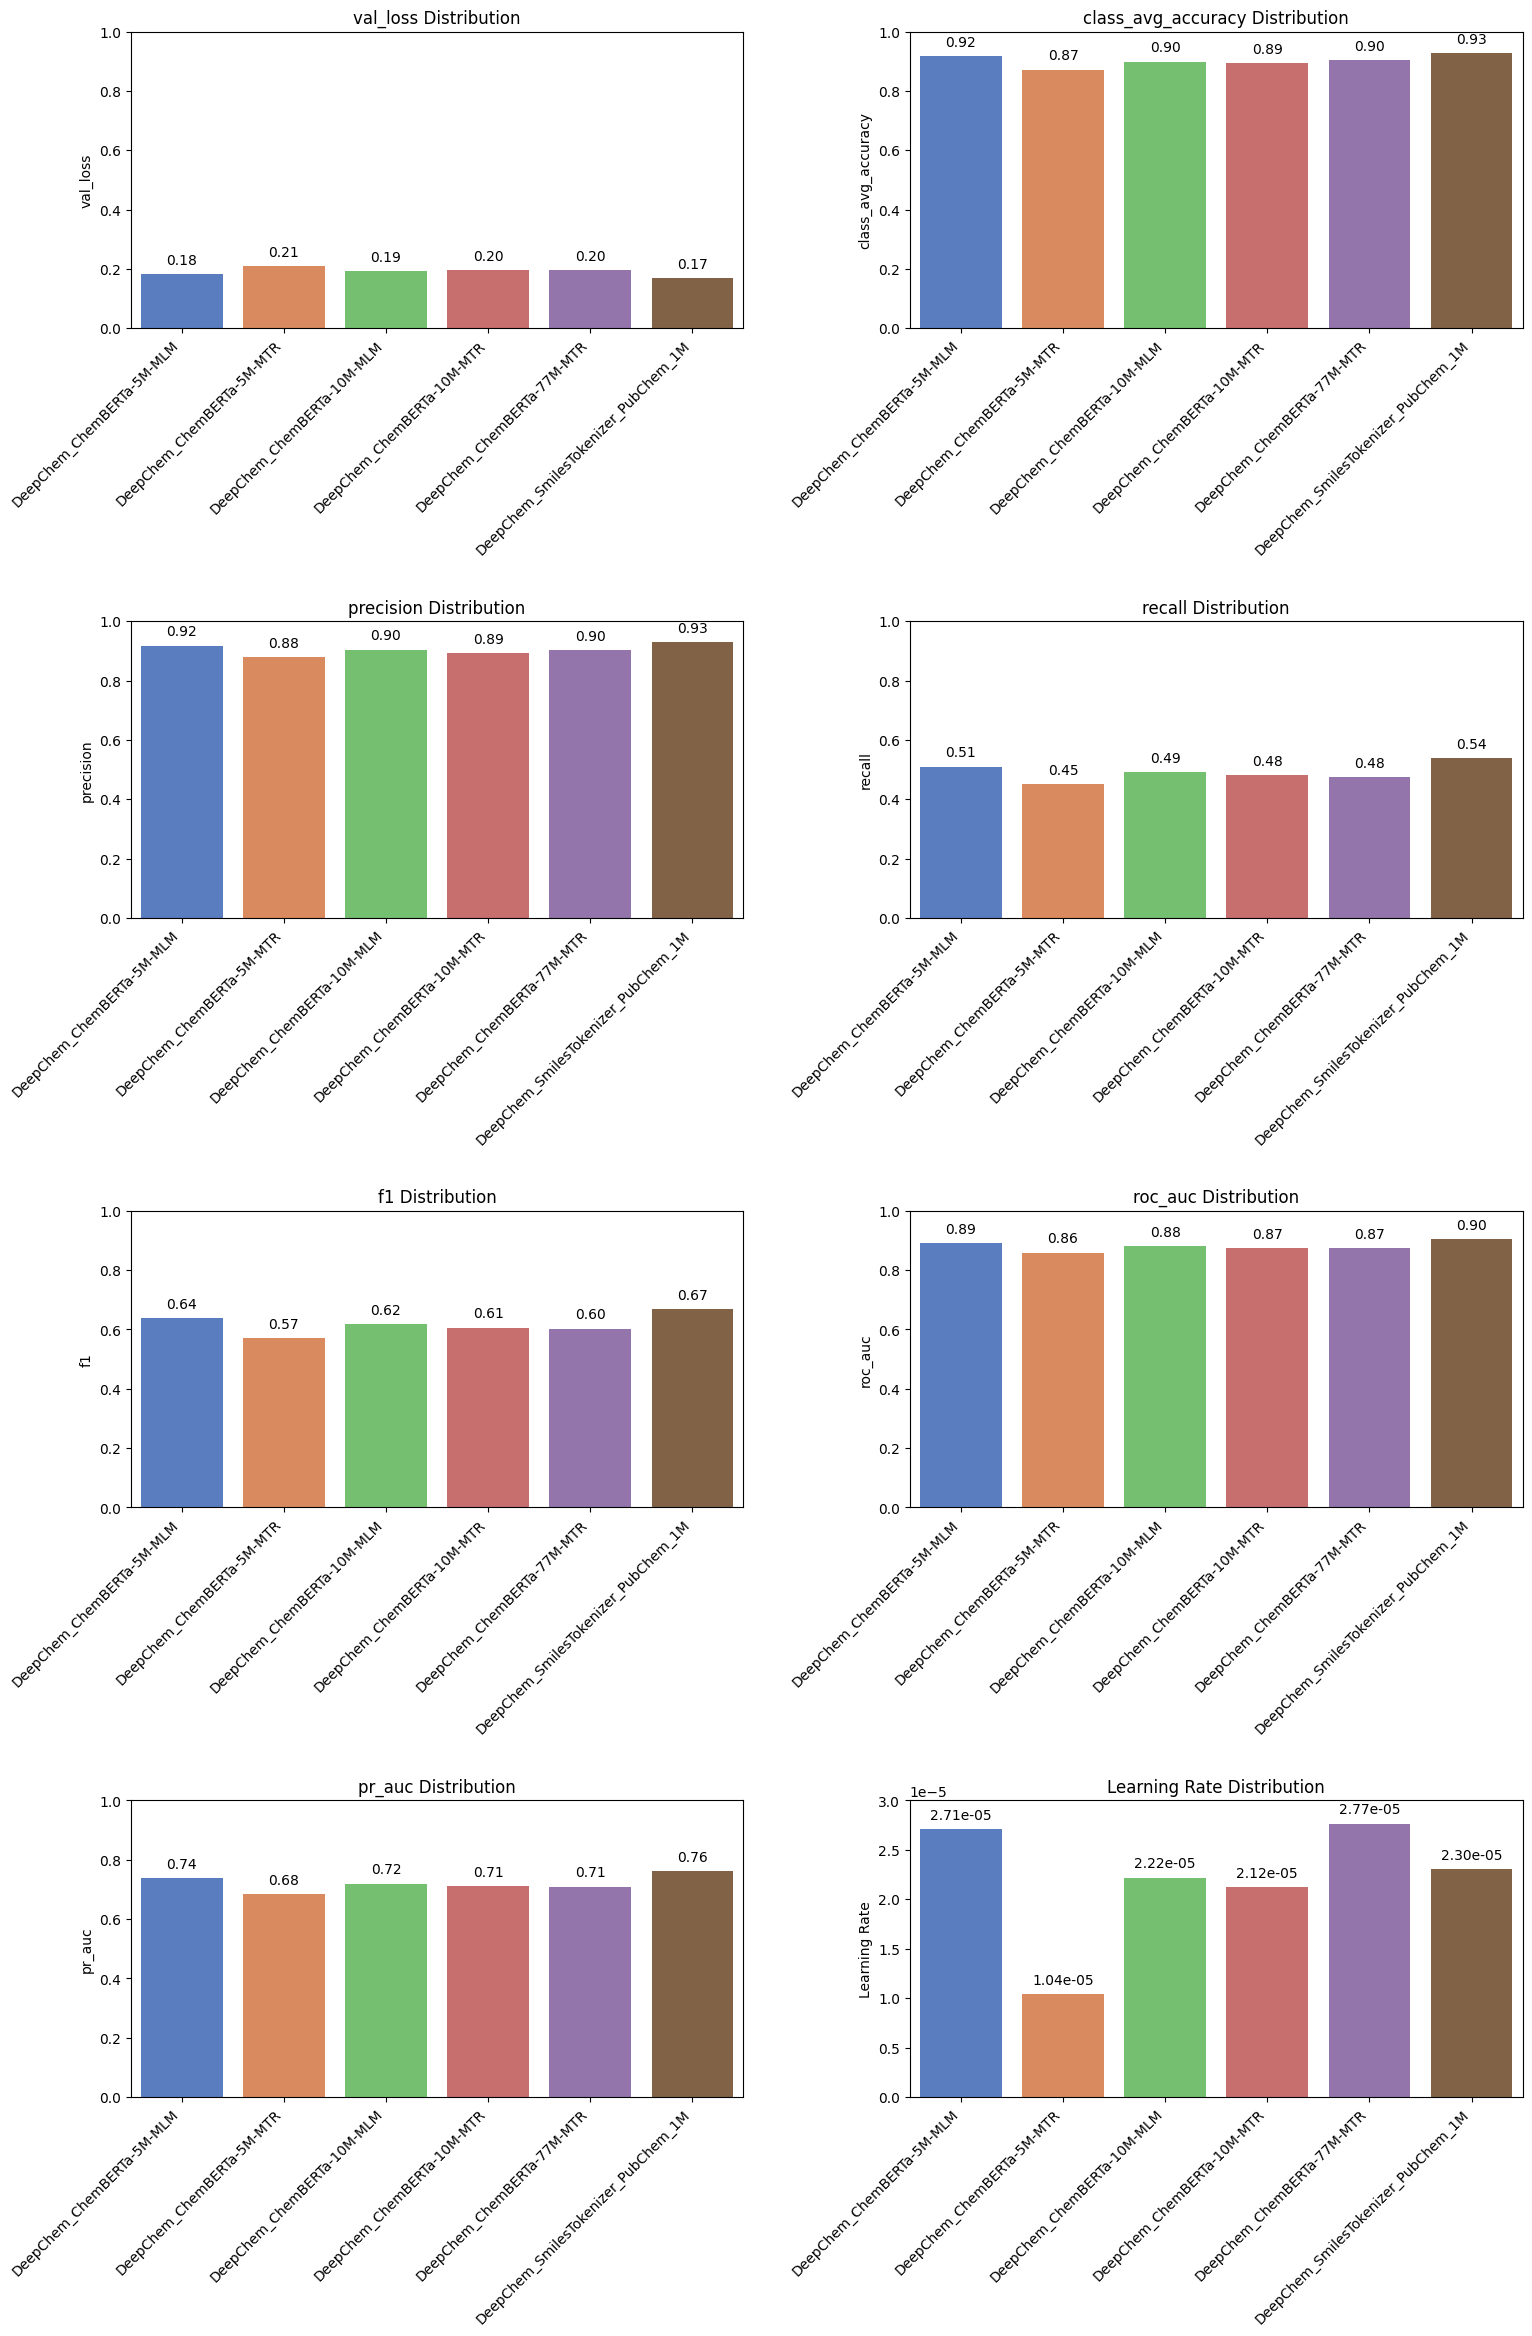

In [36]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class VisualizeConsolidatedReport:
    def __init__(self, report_file):
        self.report_file = report_file

    def load_report(self):
        with open(self.report_file, 'r') as f:
            self.report = json.load(f)

    def prepare_data(self):
        models = []
        metrics = ['val_loss', 'class_avg_accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
        data = {metric: [] for metric in metrics}
        learning_rates = []
        
        for model, results in self.report.items():
            models.append(model)
            for metric in metrics:
                data[metric].append(results['final_metrics'][metric])
            learning_rates.append(results['best_params']['learning_rate'])
        
        data['learning_rate'] = learning_rates
        df = pd.DataFrame(data, index=models)
        
        return df

    def plot_bars(self, df):
        metrics = df.columns[:-1]  # All metrics except learning_rate
        num_metrics = len(metrics)
        
        fig, axes = plt.subplots(4, 2, figsize=(16, 24))  # Adjusted to 4 rows and 2 columns
        axes = axes.flatten()
        
        for i, metric in enumerate(metrics):
            sns.barplot(x=df.index, y=df[metric], ax=axes[i], palette="muted", hue=df.index)
            axes[i].set_title(f'{metric} Distribution')
            axes[i].set_ylabel(metric)
            axes[i].set_xlabel('')
            axes[i].set_xticks(range(len(df.index)))
            axes[i].set_xticklabels(df.index, rotation=45, ha='right')
            if metric == 'val_loss':  # Adjust ylim for val_loss
                axes[i].set_ylim(0, 1)
            elif metric in ['class_avg_accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']:  # Adjust ylim for these metrics
                axes[i].set_ylim(0, 1)
            if axes[i].get_legend() is not None:
                axes[i].get_legend().remove()
            for p in axes[i].patches:
                height = p.get_height()
                axes[i].annotate(f'{height:.2f}', 
                                (p.get_x() + p.get_width() / 2., height),
                                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
        
        # Adding learning_rate plot to the last subplot
        sns.barplot(x=df.index, y=df['learning_rate'], ax=axes[-1], palette="muted", hue=df.index)
        axes[-1].set_title('Learning Rate Distribution')
        axes[-1].set_ylabel('Learning Rate')
        axes[-1].set_xlabel('')
        axes[-1].set_ylim(0, 3.0e-5)
        axes[-1].set_xticks(range(len(df.index)))
        axes[-1].set_xticklabels(df.index, rotation=45, ha='right')
        if axes[-1].get_legend() is not None:
            axes[-1].get_legend().remove()
        for p in axes[-1].patches:
            height = p.get_height()
            axes[-1].annotate(f'{height:.2e}', 
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='center', xytext=(0, 10), textcoords='offset points')
        
        # Hide any remaining empty subplots
        for j in range(num_metrics, len(axes) - 1):
            fig.delaxes(axes[j])
        
        plt.tight_layout(pad=3.0)  # Adjusted padding for more spacing
        plt.savefig('consolidated_report_bar_plots_with_lr.png')
        plt.show()

if __name__ == "__main__":
    report_file = 'consolidated_report.json'
    visualizer = VisualizeConsolidatedReport(report_file)
    visualizer.load_report()
    df = visualizer.prepare_data()
    visualizer.plot_bars(df)
